In [ ]:
%load_ext sql

import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv(encoding='utf-8-sig')

mysql_host = os.getenv("MYSQL_HOST")
mysql_user = os.getenv("MYSQL_USER")
mysql_password = os.getenv("MYSQL_PASSWORD")
mysql_database = os.getenv("MYSQL_DATABASE")

connection_string = f"mysql+pymysql://{mysql_user}:{mysql_password}@{mysql_host}/{mysql_database}"

# 🔥 Force SQL magic to use THIS connection string — prevents the error
%sql $connection_string

print("✅ MySQL Connected Successfully!")


# PART 2 - Clustering data to unveil Maji Ndogo's water crisis

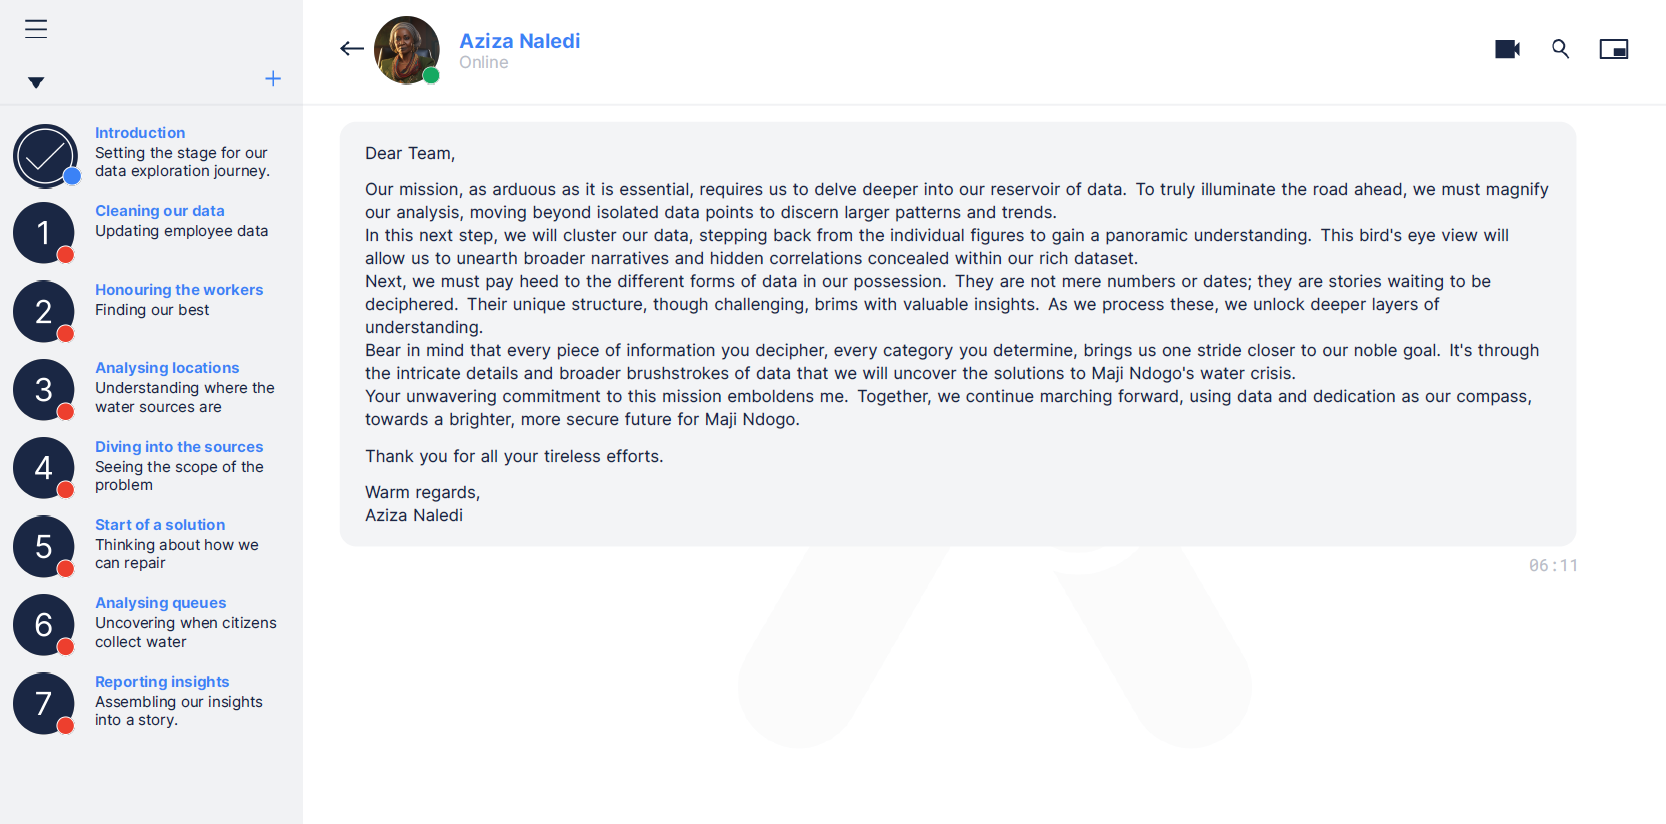

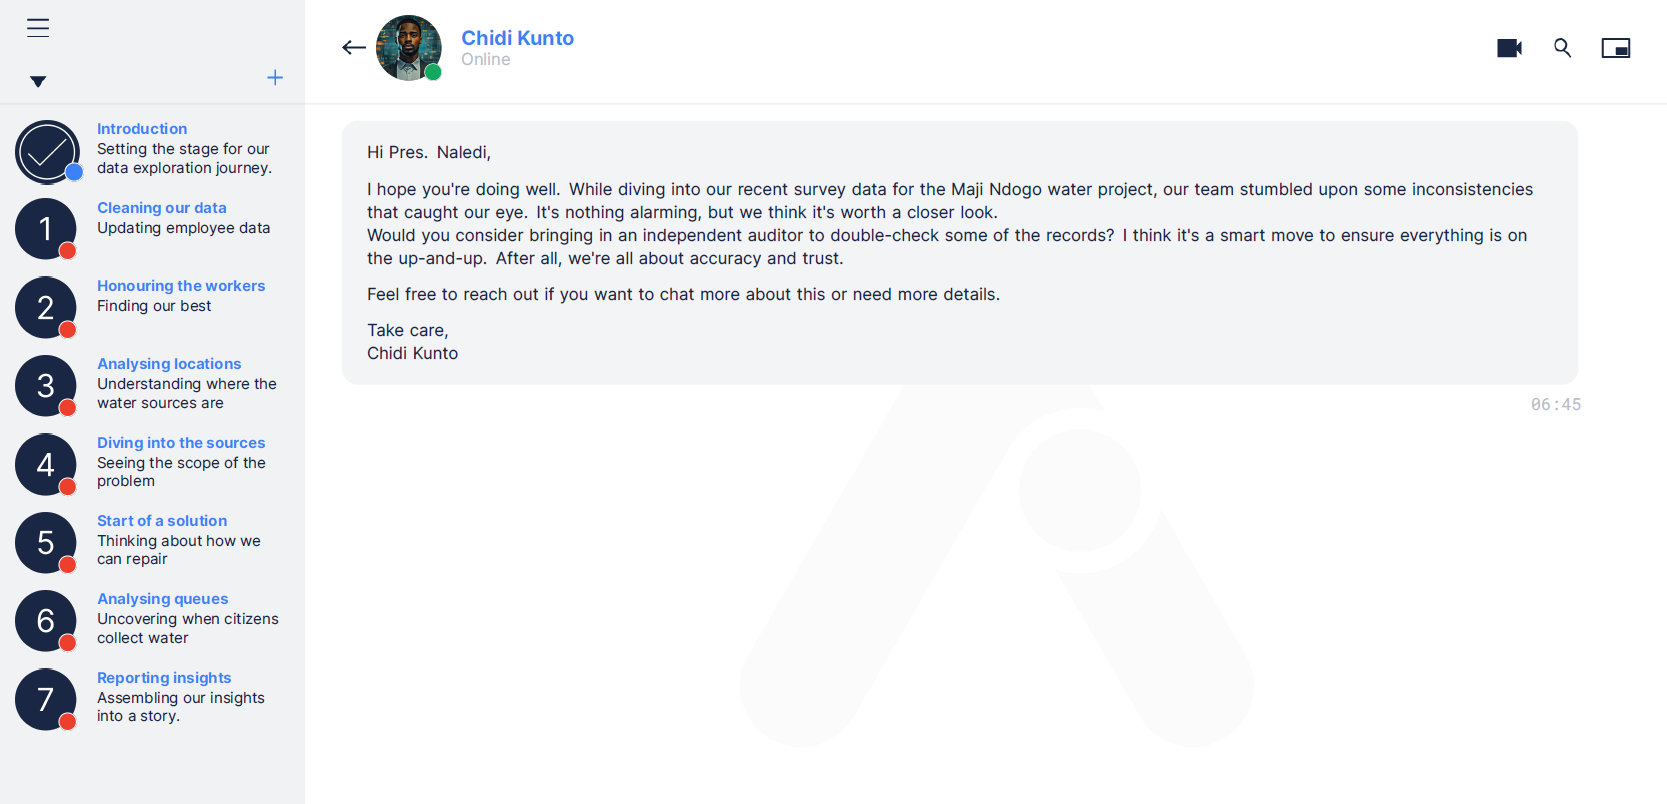

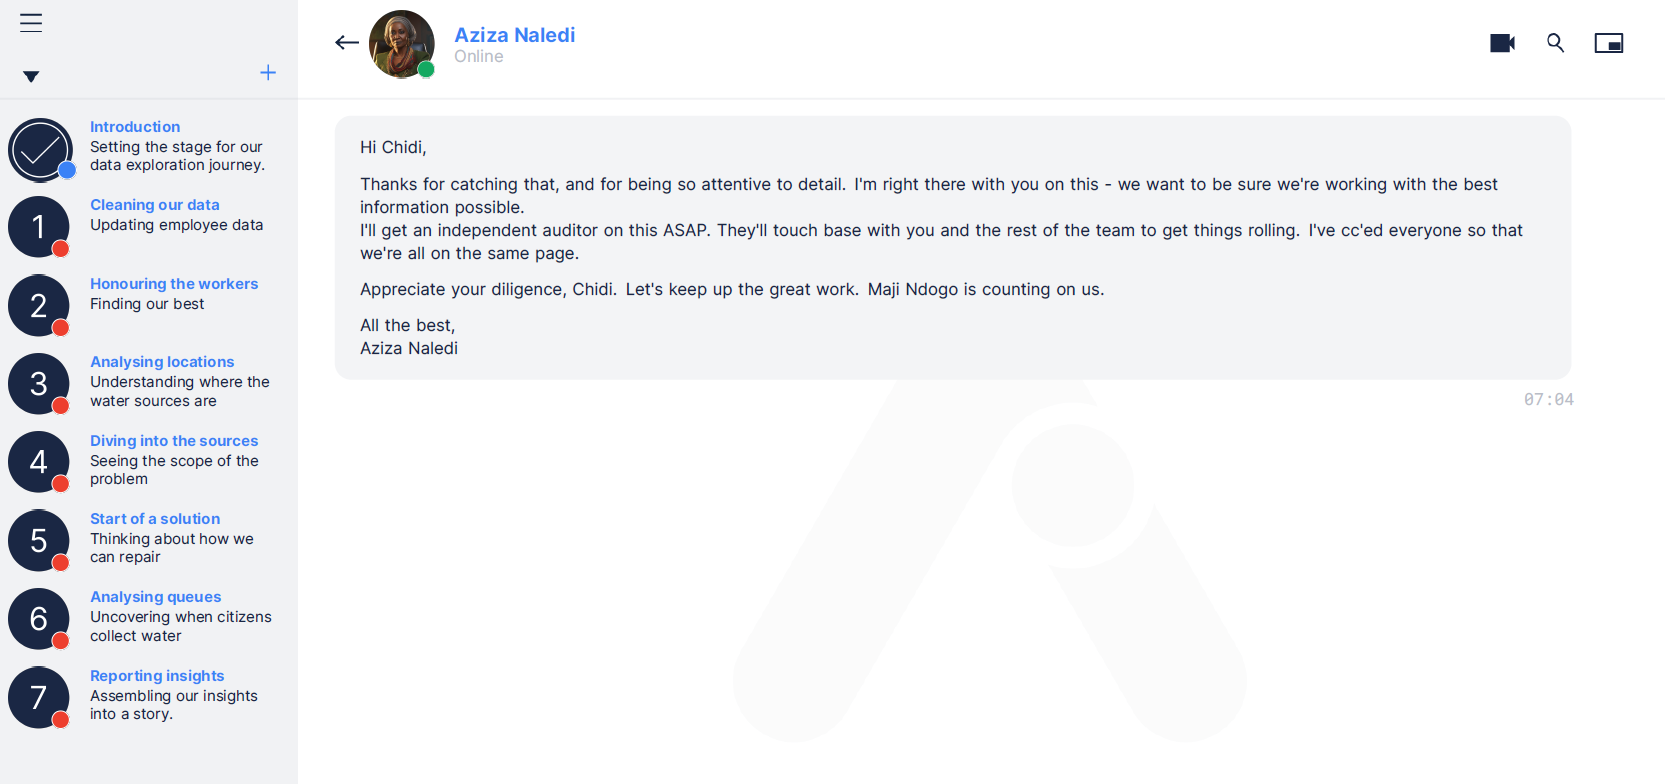

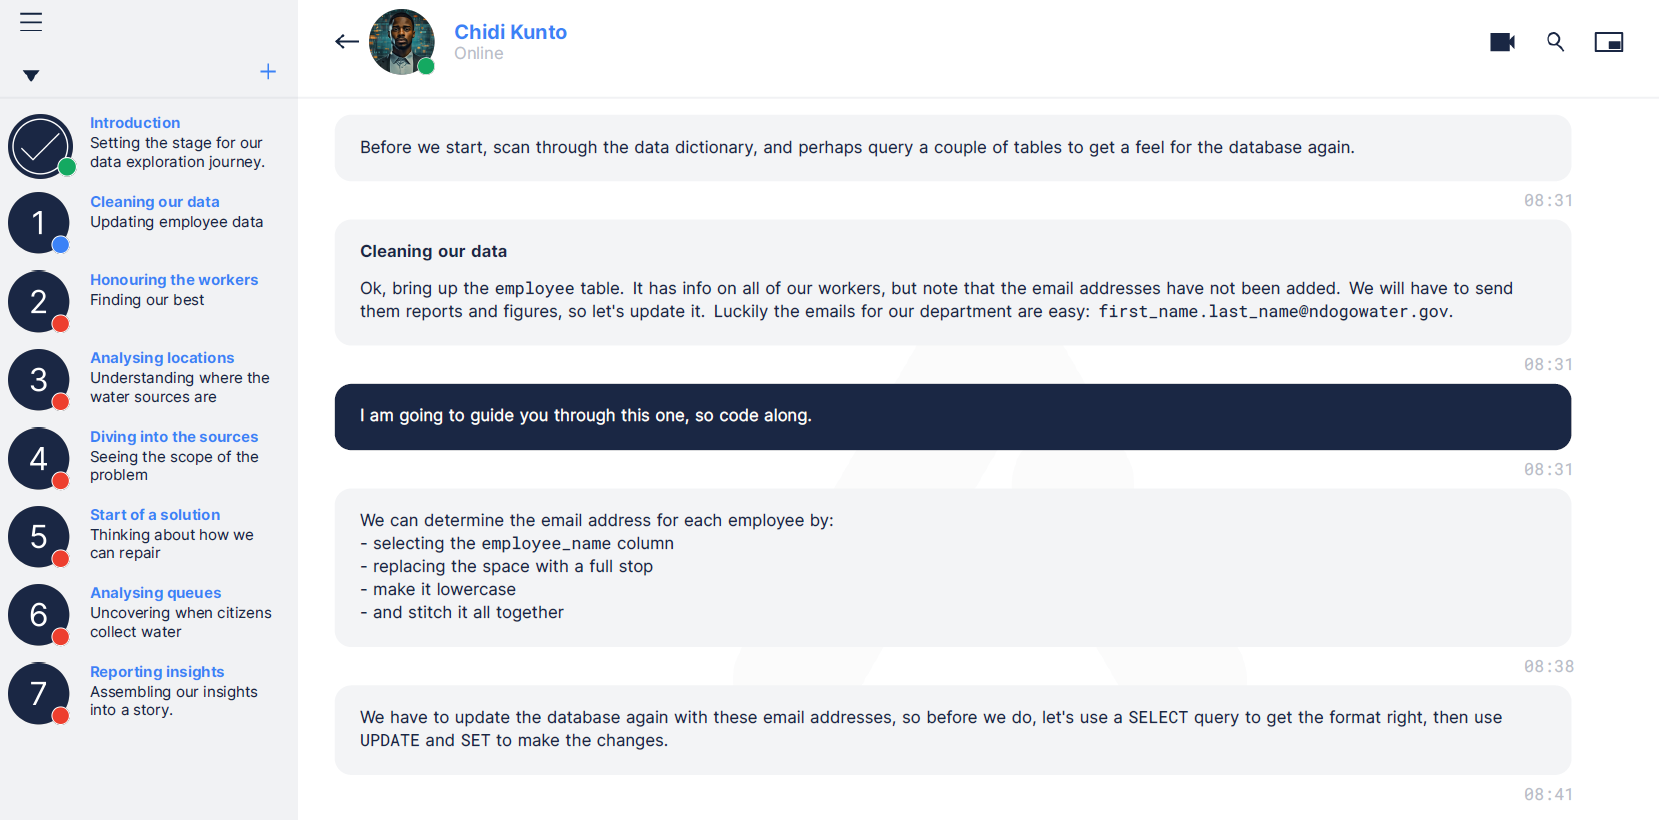

In [ ]:
%%sql
SELECT * FROM employee;

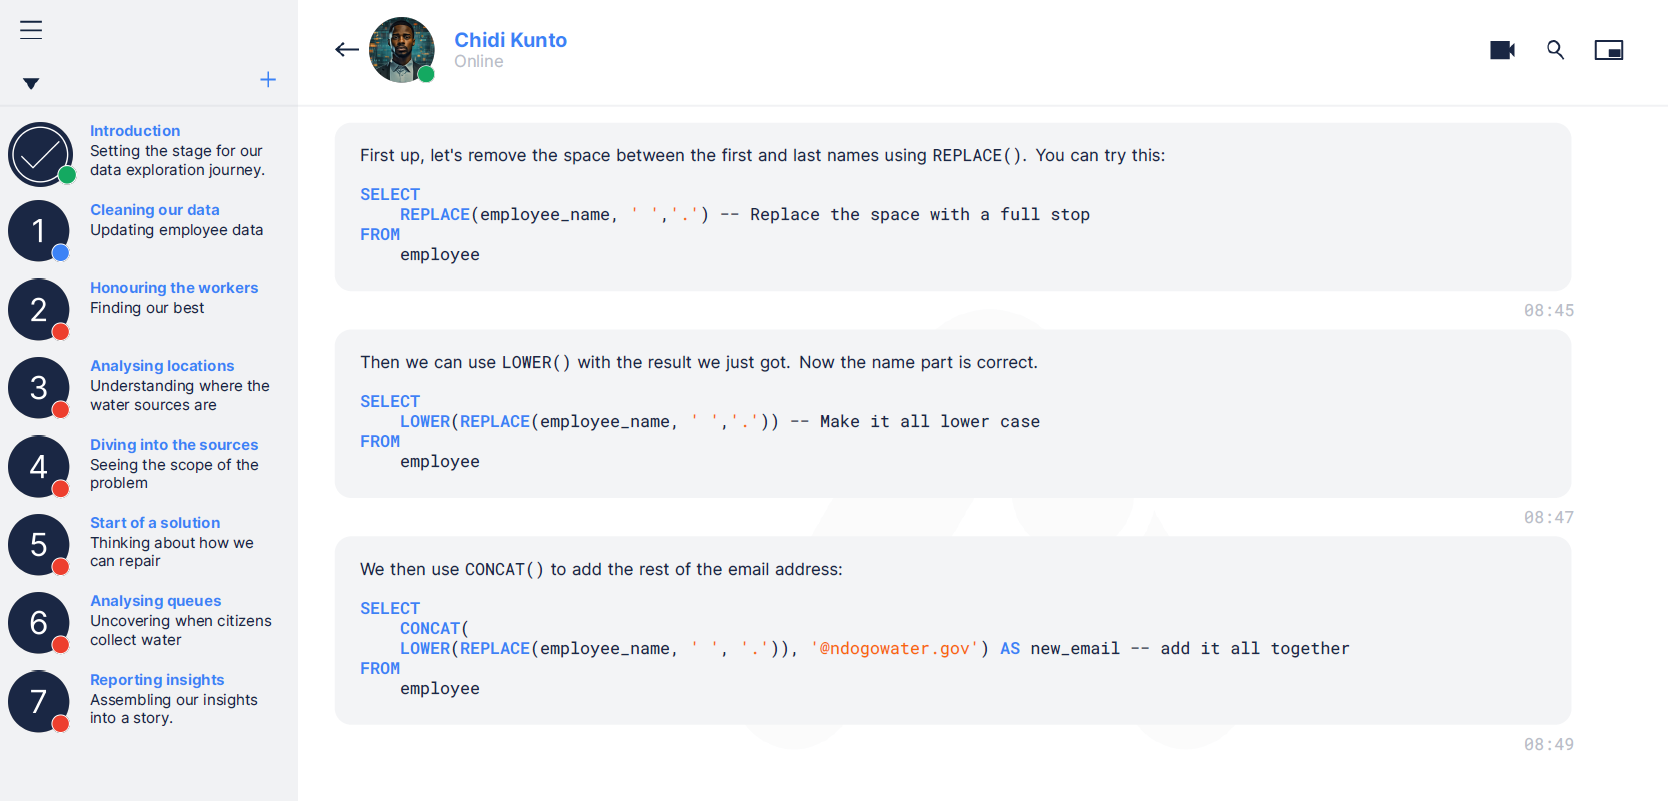

In [ ]:
%%sql
UPDATE employee SET email = CONCAT(LOWER(REPLACE(employee_name, ' ', '.')), '@ndogowater.gov')

In [ ]:
%%sql
SELECT * FROM employee;

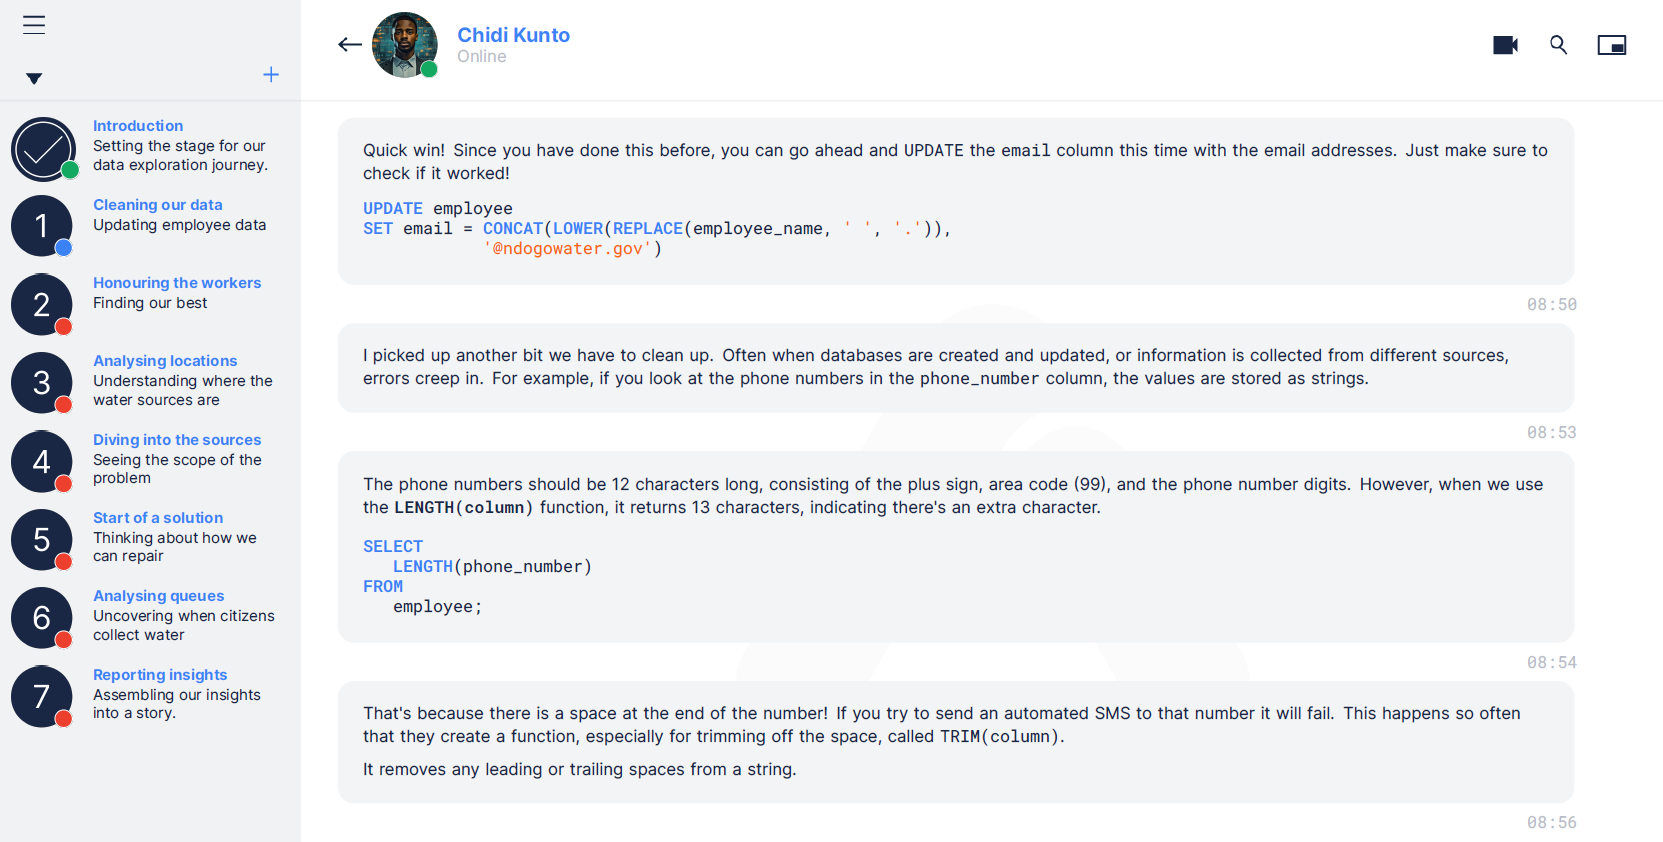

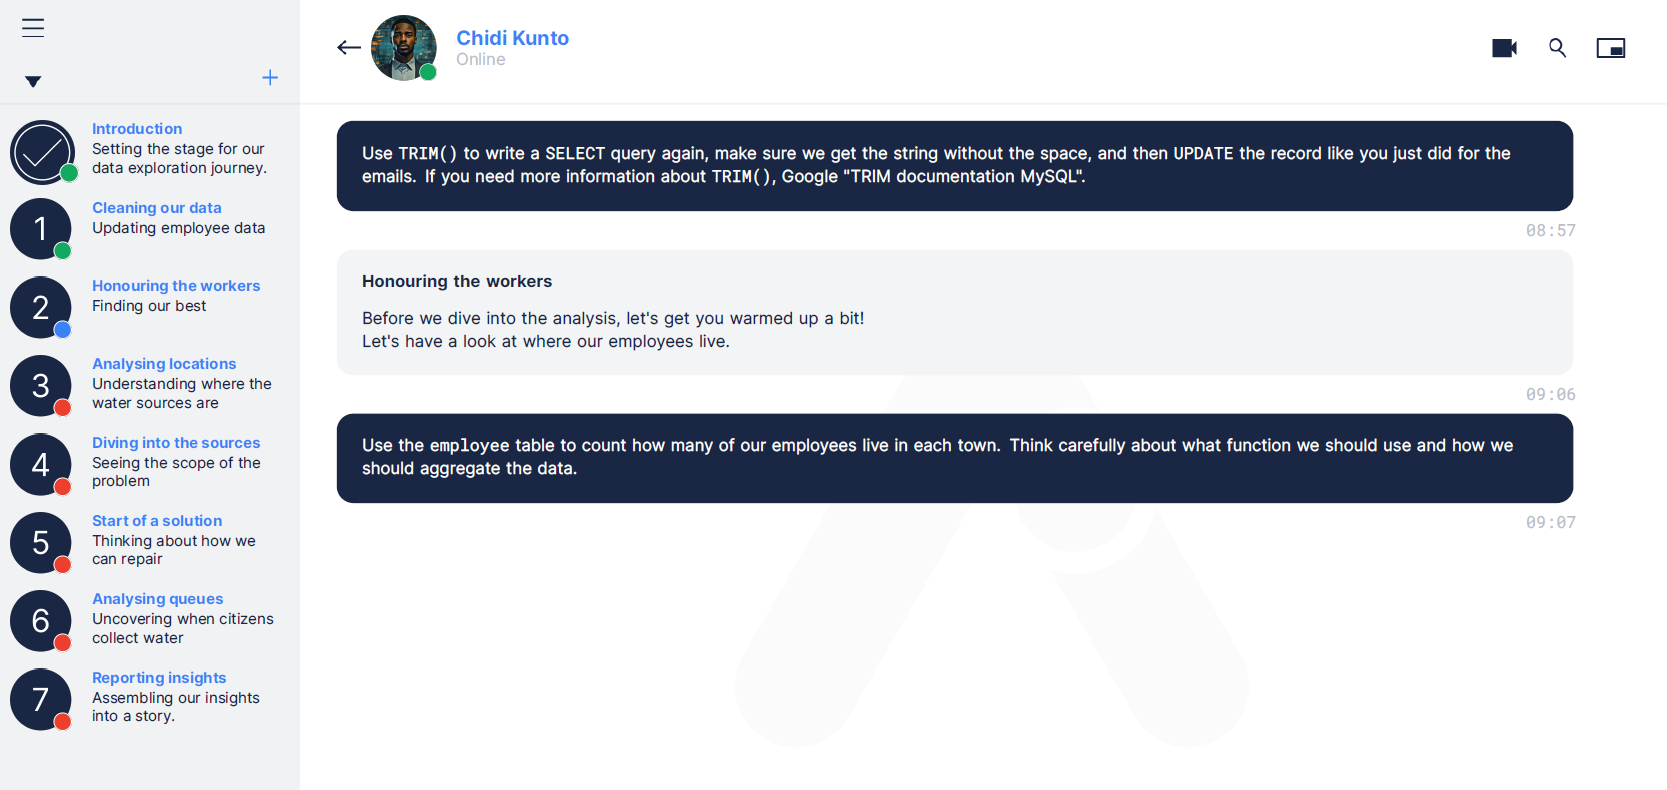

In [ ]:
%%sql
UPDATE employee
SET email = CONCAT(LOWER(REPLACE(TRIM(employee_name), ' ', '.')), '@ndogowater.gov');


In [ ]:
%%sql
SELECT 
    COUNT(*) AS count_of_Employees,
    town_name 
FROM employee
GROUP BY town_name
ORDER BY count_of_Employees;

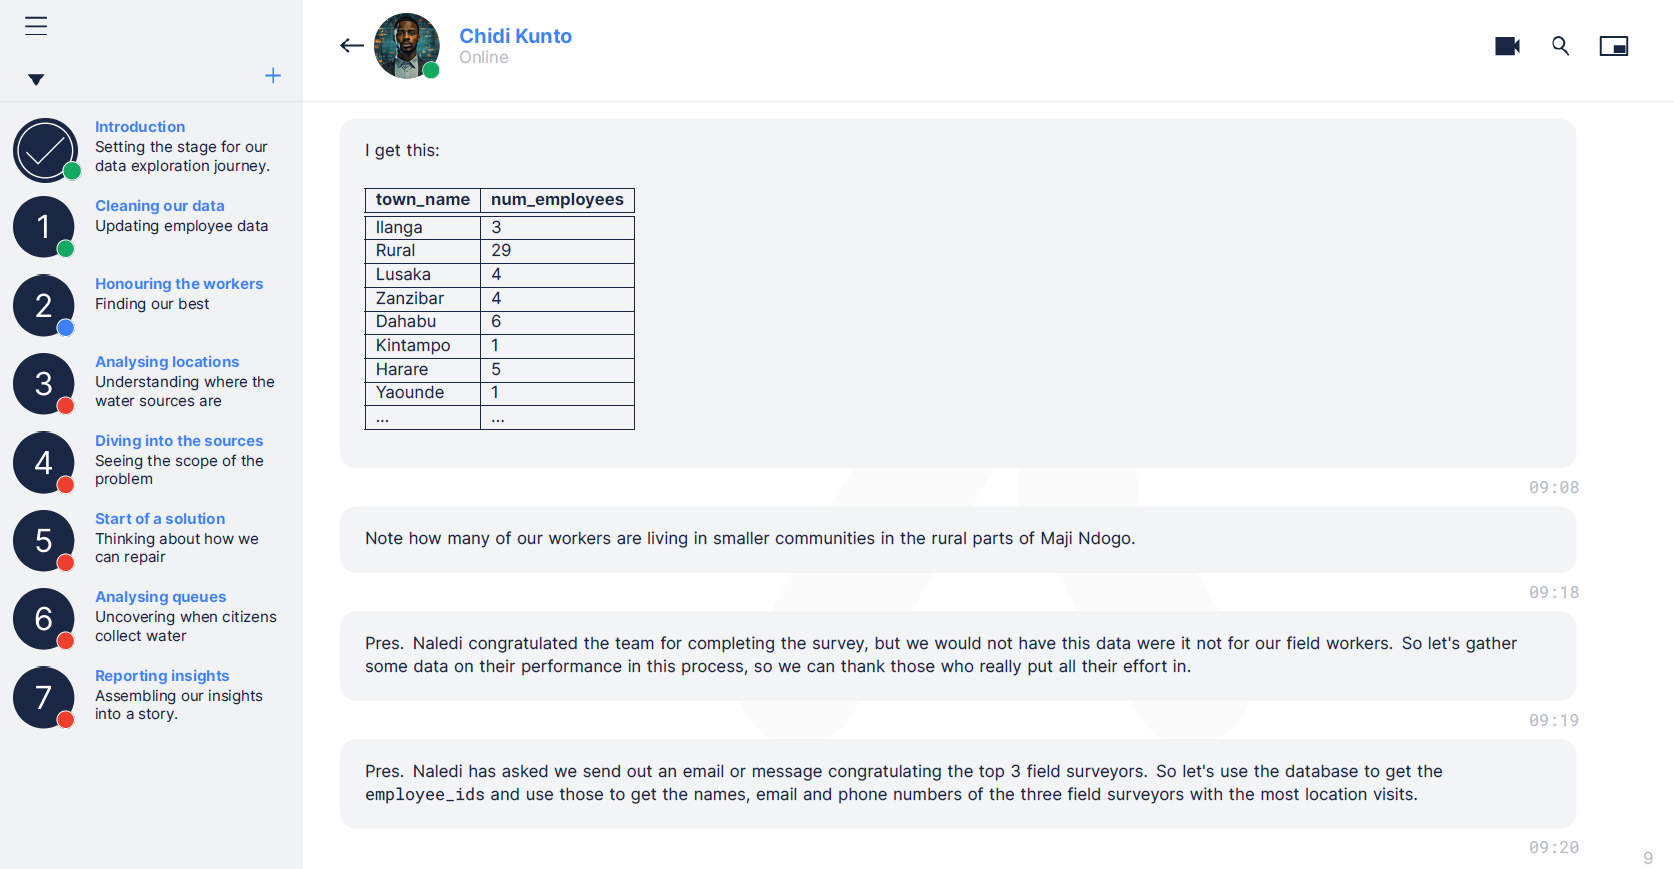

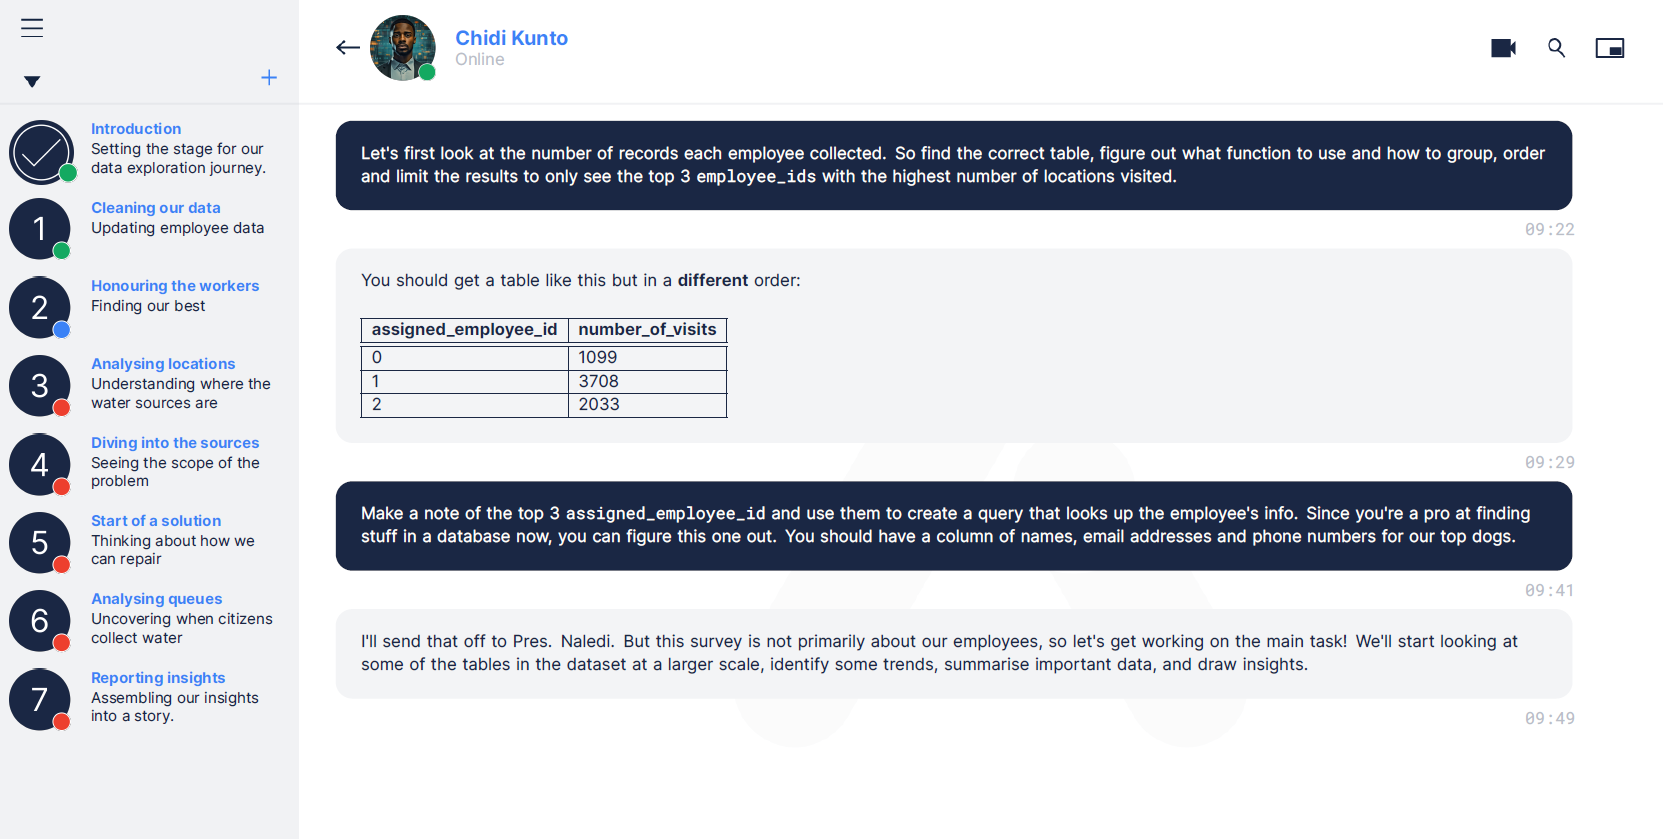

In [ ]:
%%sql
SELECT assigned_employee_id, 
COUNT(*) AS visit_count
FROM visits
GROUP BY assigned_employee_id
ORDER BY visit_count DESC LIMIT 3;

In [ ]:
%%sql
SELECT 
    V.assigned_employee_id,
    E.employee_name, 
    E.email,
    E.phone_number,
    COUNT(V.location_id) AS total_visits
FROM visits V 
JOIN employee E ON V.assigned_employee_id = E.assigned_employee_id
GROUP BY V.assigned_employee_id, E.employee_name, E.email, E.phone_number
ORDER BY total_visits DESC LIMIT 3;

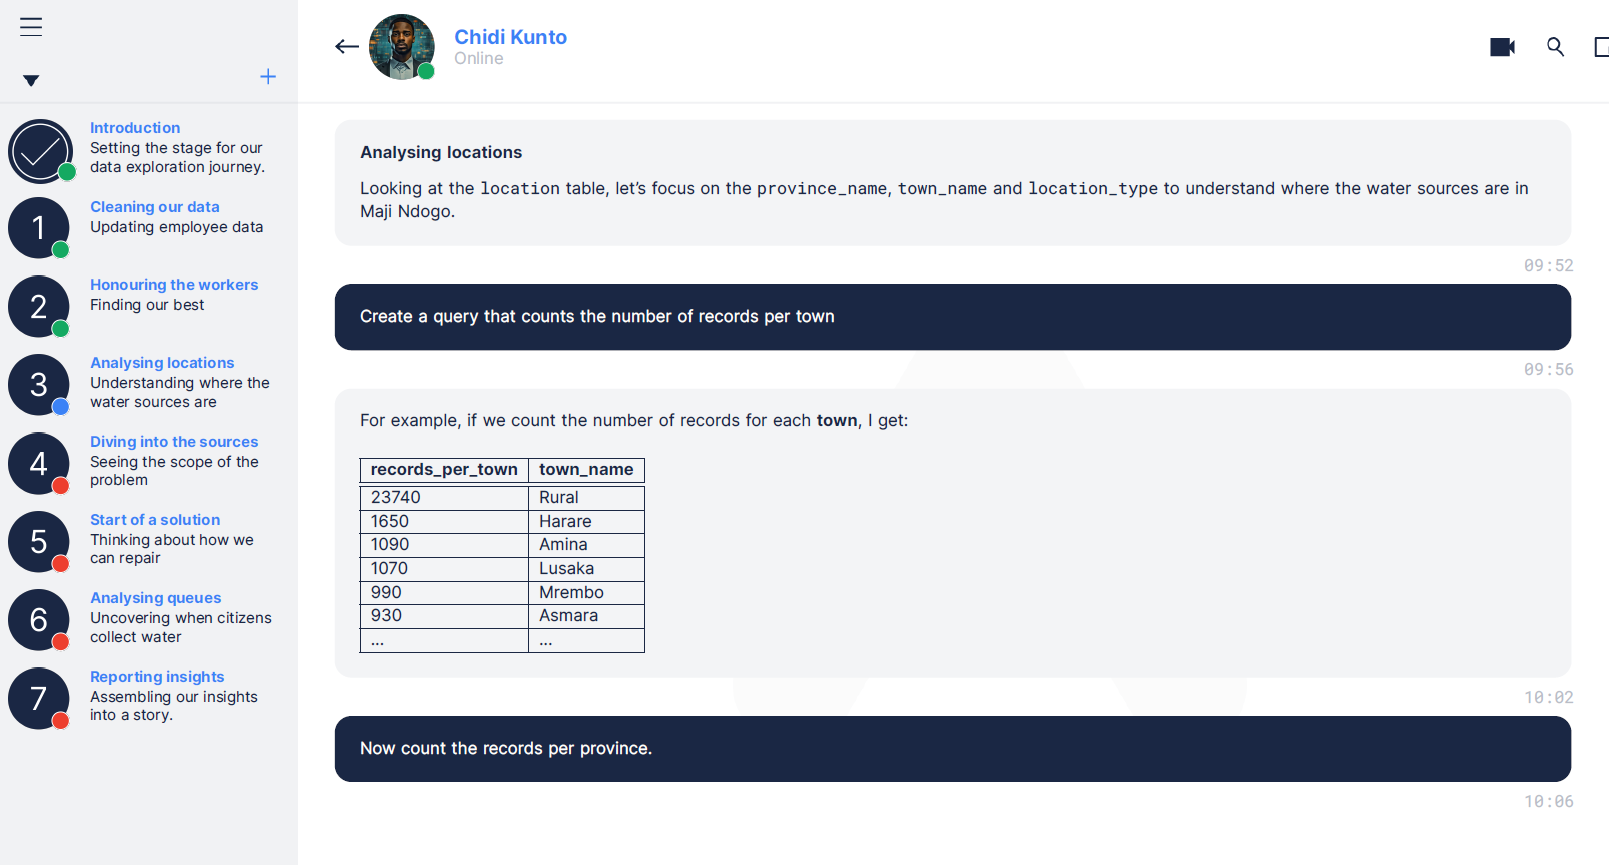

In [ ]:
%%sql
SELECT 
    COUNT(V.record_id) AS total_visits,
    E.town_name
FROM visits V 
JOIN employee E ON V.assigned_employee_id = E.assigned_employee_id
GROUP BY town_name
ORDER BY total_visits DESC;

In [ ]:
%%sql
SELECT 
    COUNT(*) AS records_per_town,
    town_name
FROM Location 
GROUP BY town_name
ORDER BY records_per_town DESC;

In [ ]:
%%sql
SELECT 
    COUNT(*) AS records_per_town,
    province_name
FROM Location 
GROUP BY province_name
ORDER BY records_per_town DESC;

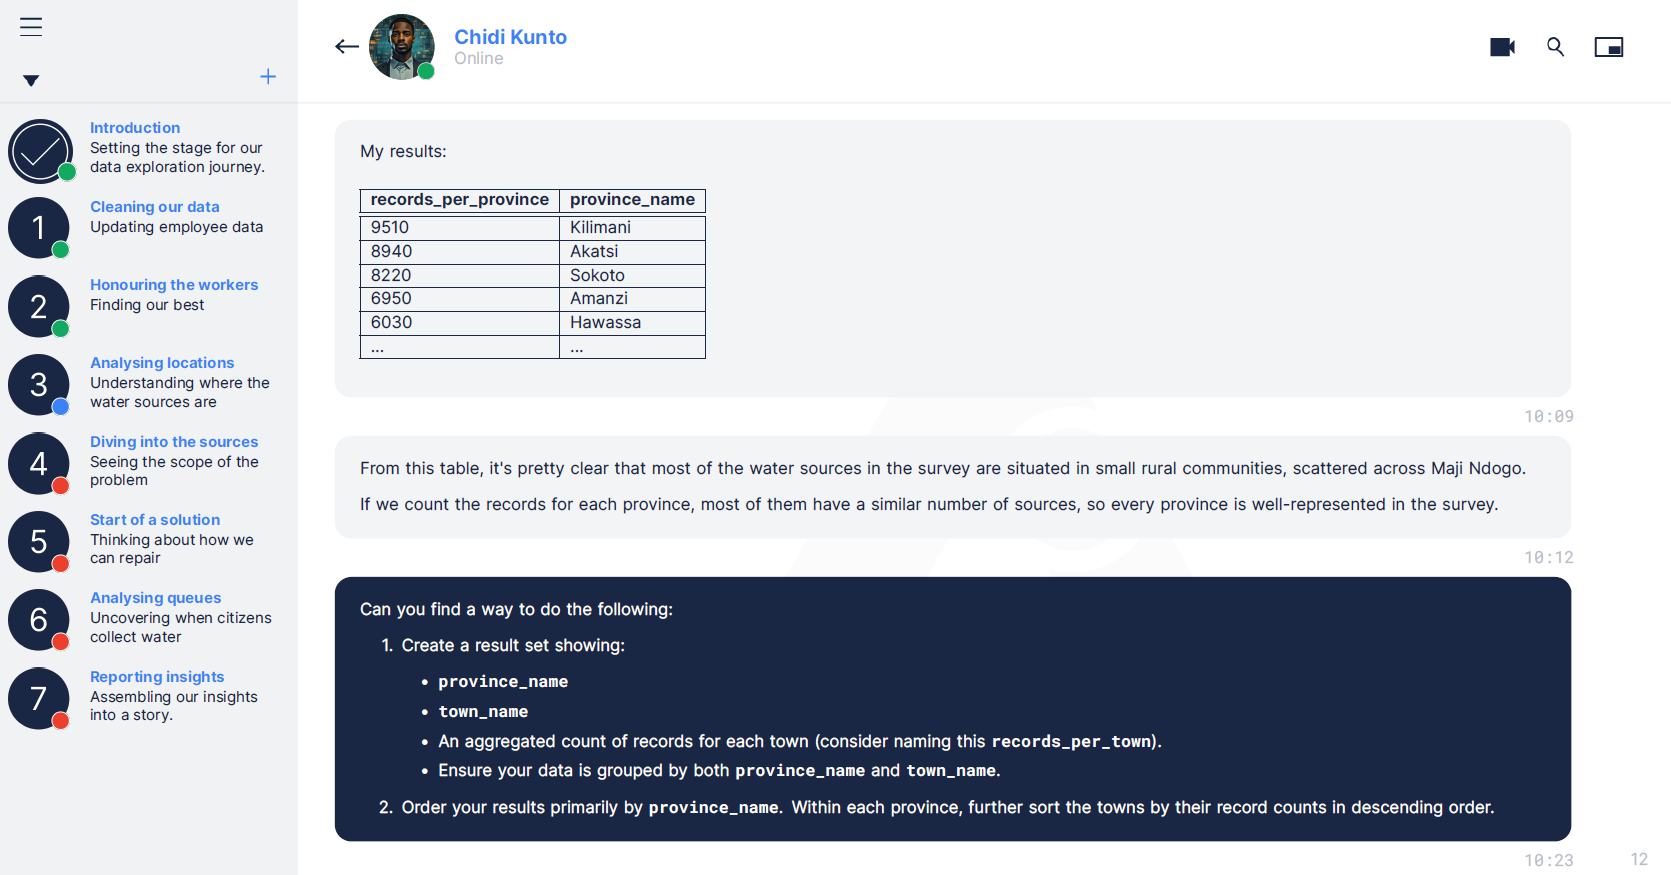

In [ ]:
%%sql
SELECT 
    province_name,
    town_name,
    COUNT(*) AS records_per_town
FROM Location 
GROUP BY province_name, town_name
ORDER BY province_name, town_name DESC;

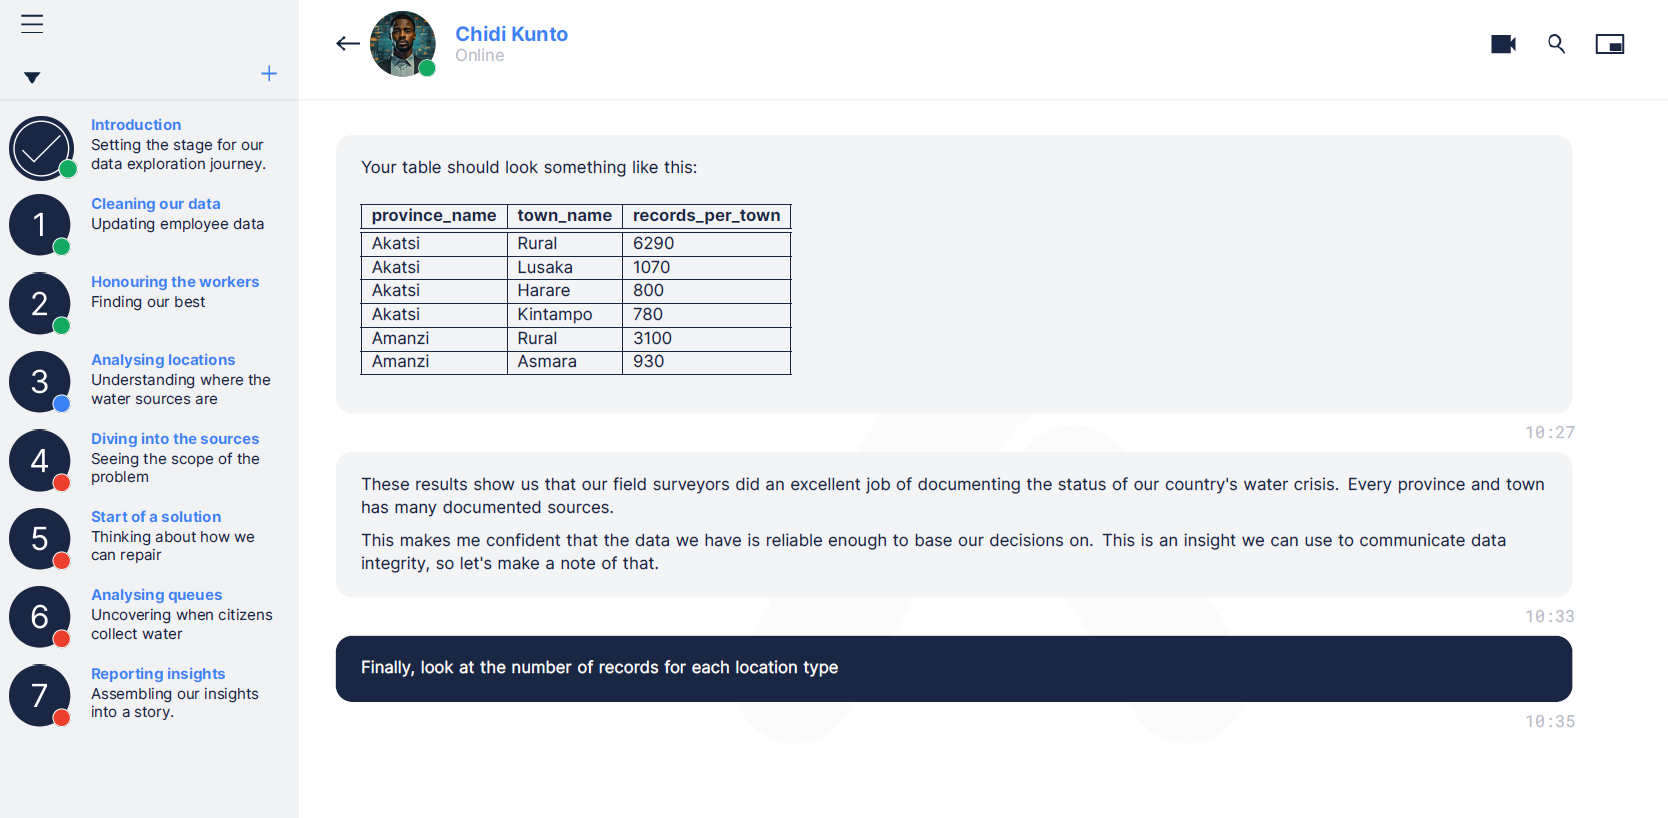

In [ ]:
%%sql
SELECT 
    COUNT(*) AS num_sources,
    location_type,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 0) AS percentage
FROM location
GROUP BY location_type;

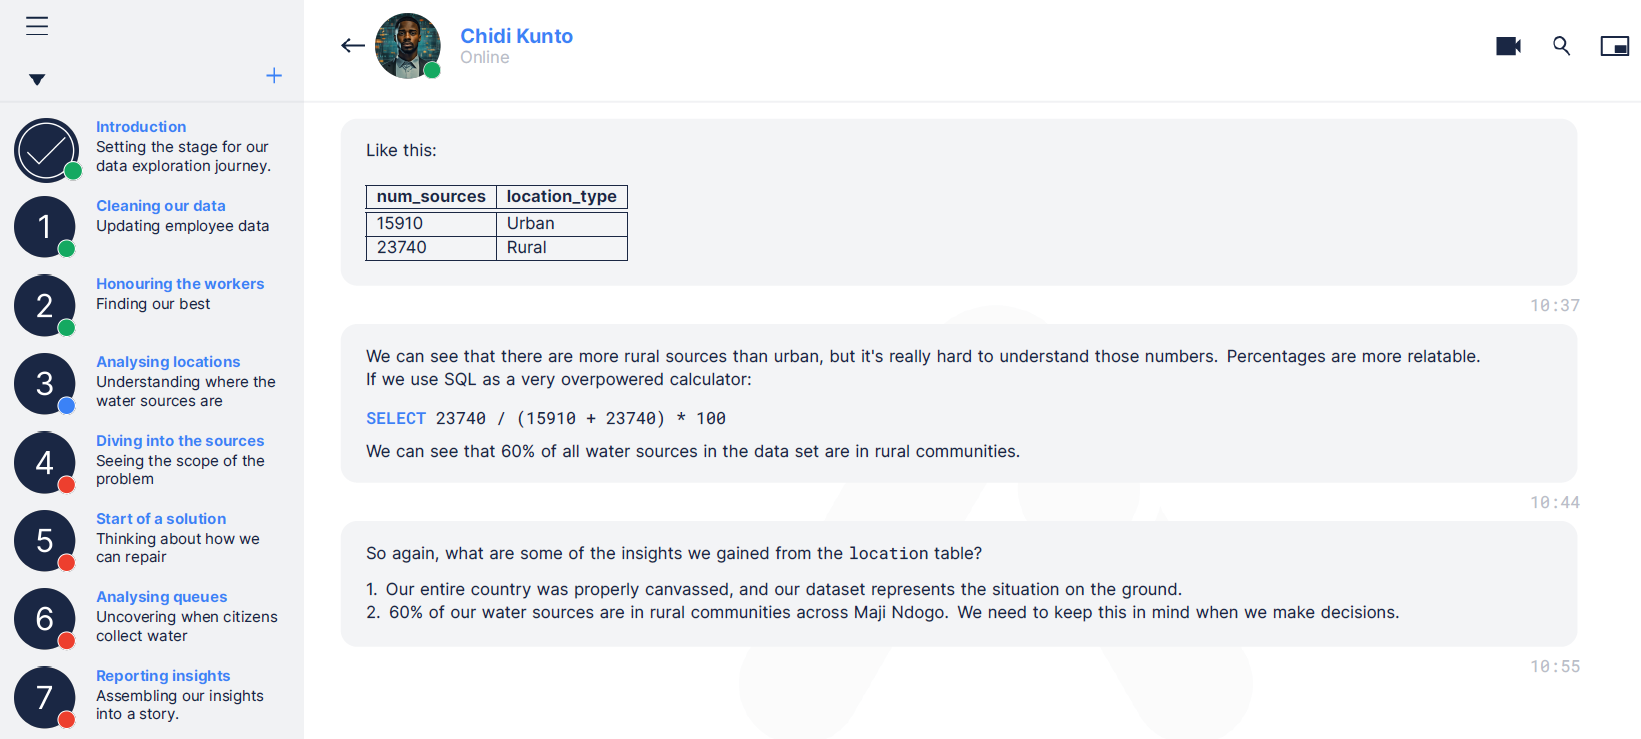

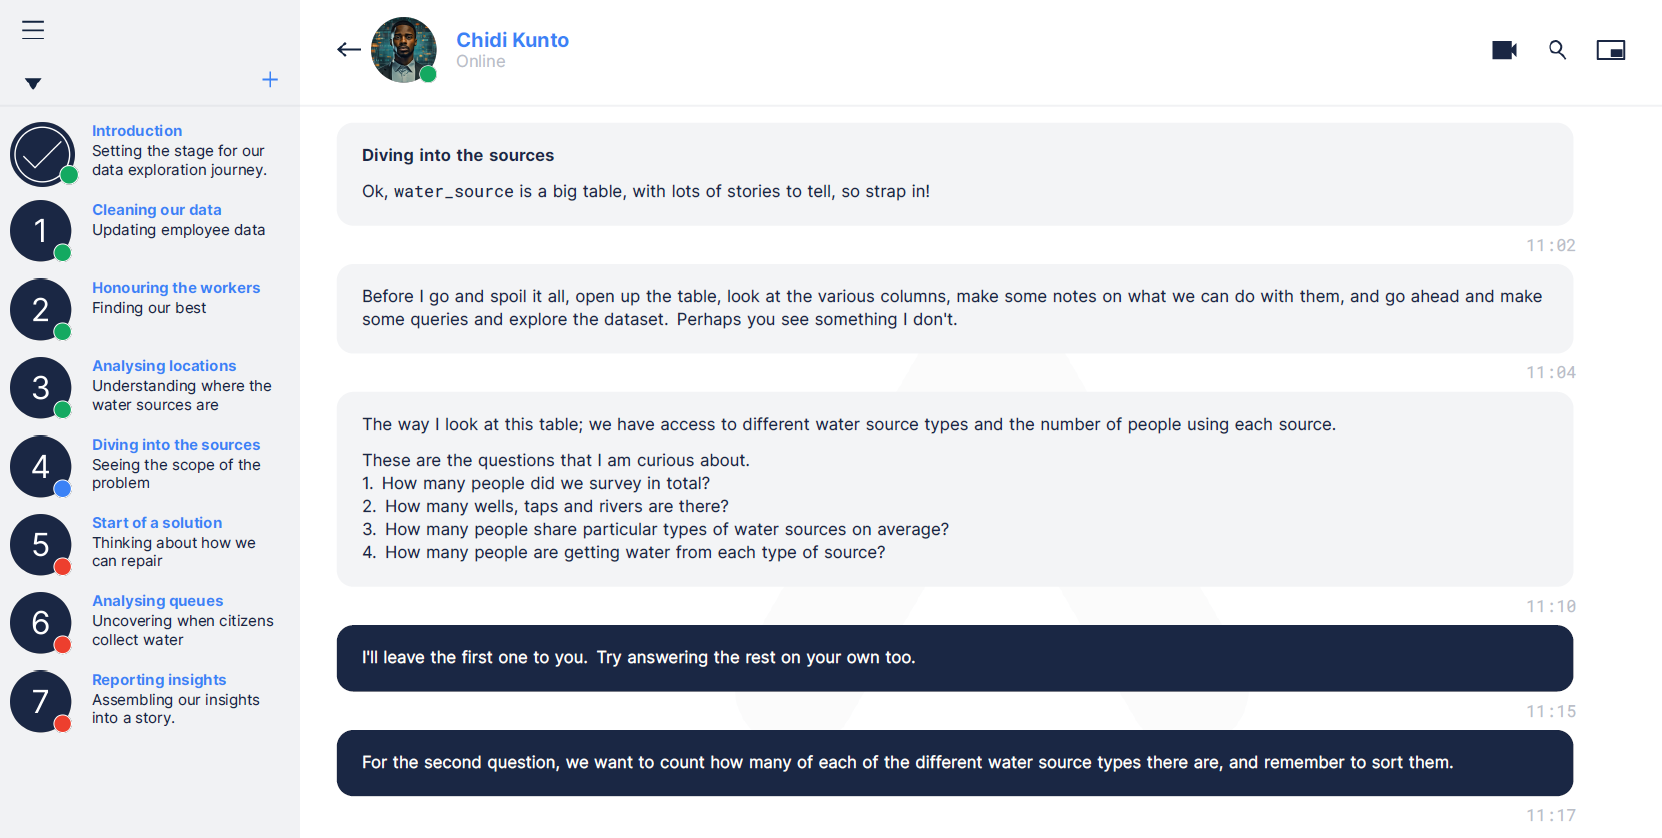

In [ ]:
%%sql
-- How many people did we survey in total?
SELECT SUM(number_of_people_served) AS Total_num_of_people_served FROM water_source;

In [ ]:
%%sql
-- How many wells, taps and rivers are there?
SELECT 
    type_of_water_source,
    COUNT(*) AS number_of_sources
FROM water_source
GROUP BY type_of_water_source;

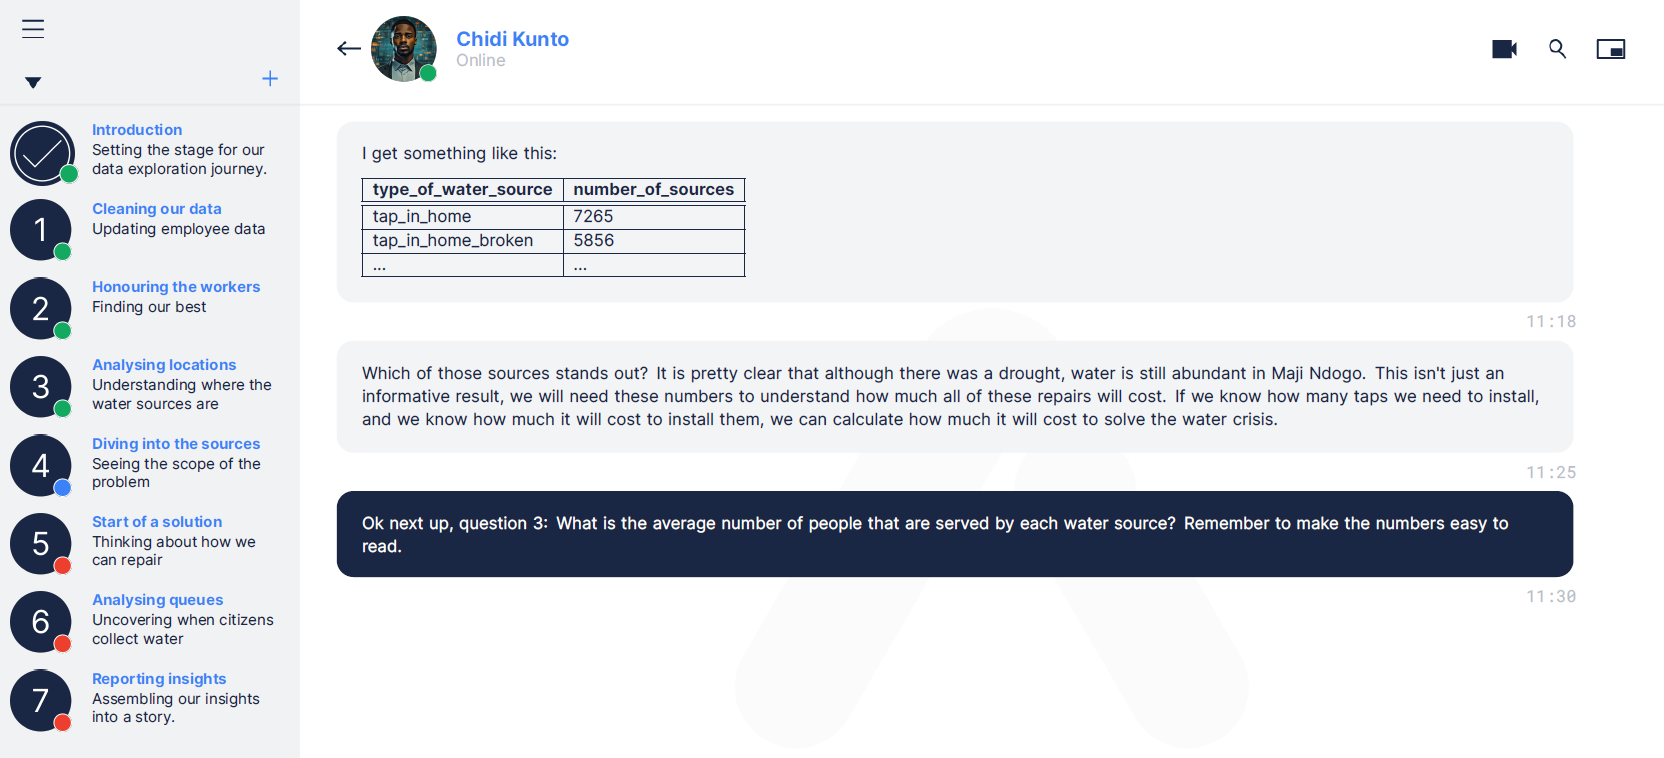

In [ ]:
%%sql
-- How many people share particular types of water sources on average?
SELECT 
    type_of_water_source,
    ROUND(AVG(number_of_people_served),0) AS ave_people_per_source
FROM water_source
GROUP BY type_of_water_source;

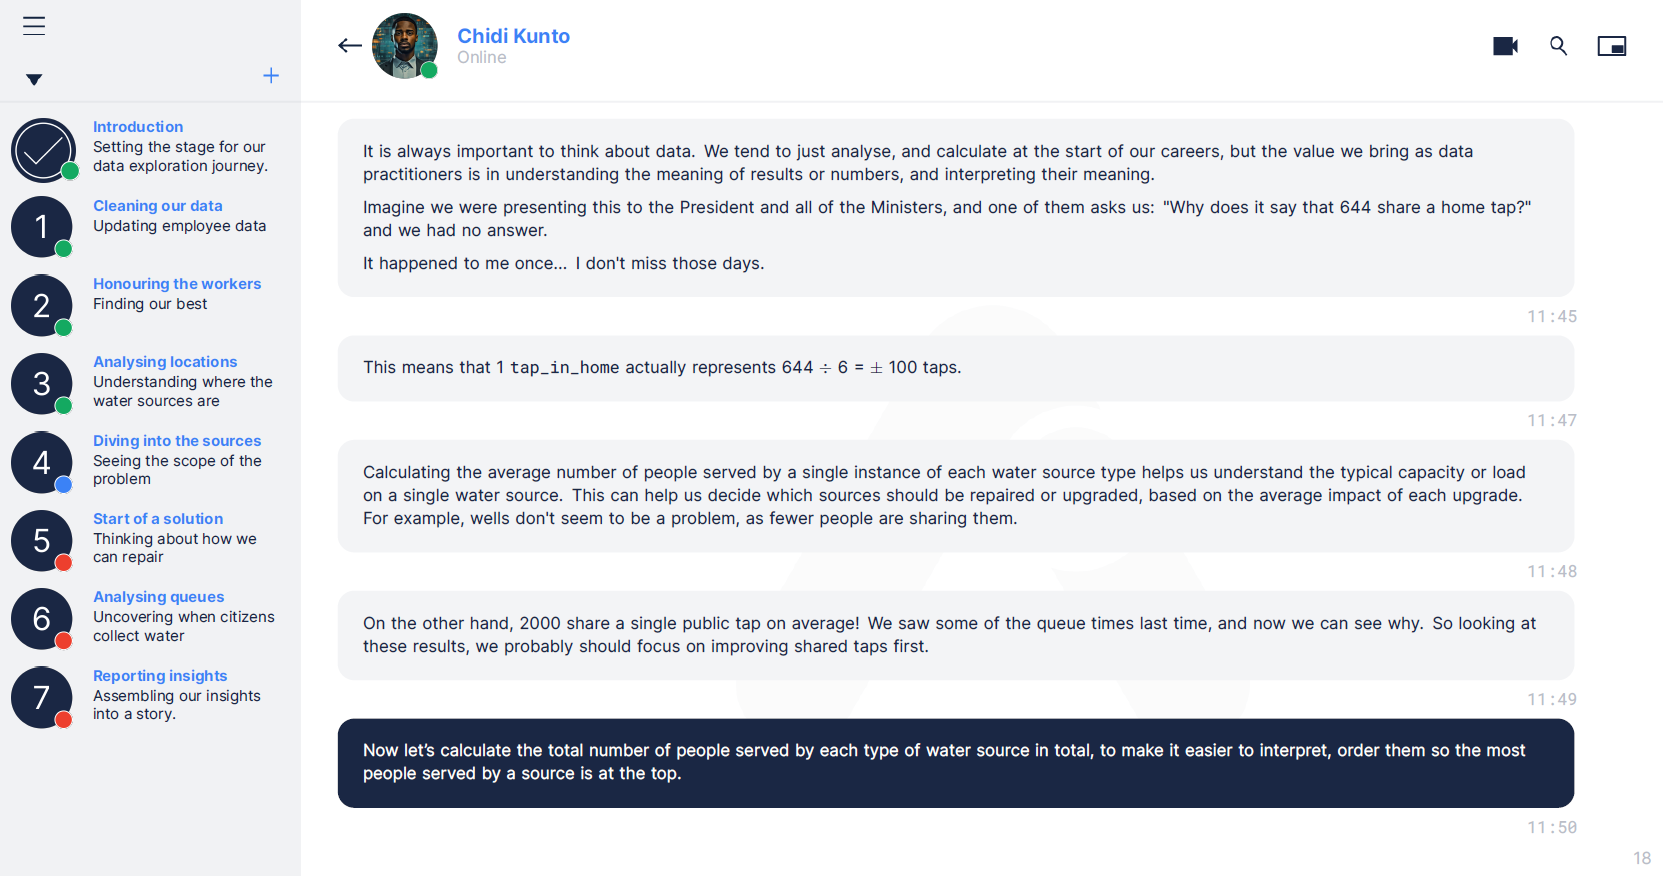

In [ ]:
%%sql
SELECT 
    type_of_water_source, 
    SUM(number_of_people_served) AS population_served,
    ROUND(SUM(number_of_people_served) * 100.0 / (SELECT SUM(number_of_people_served) FROM water_source),0) AS percentage
FROM water_source
GROUP BY type_of_water_source
ORDER BY population_served DESC;


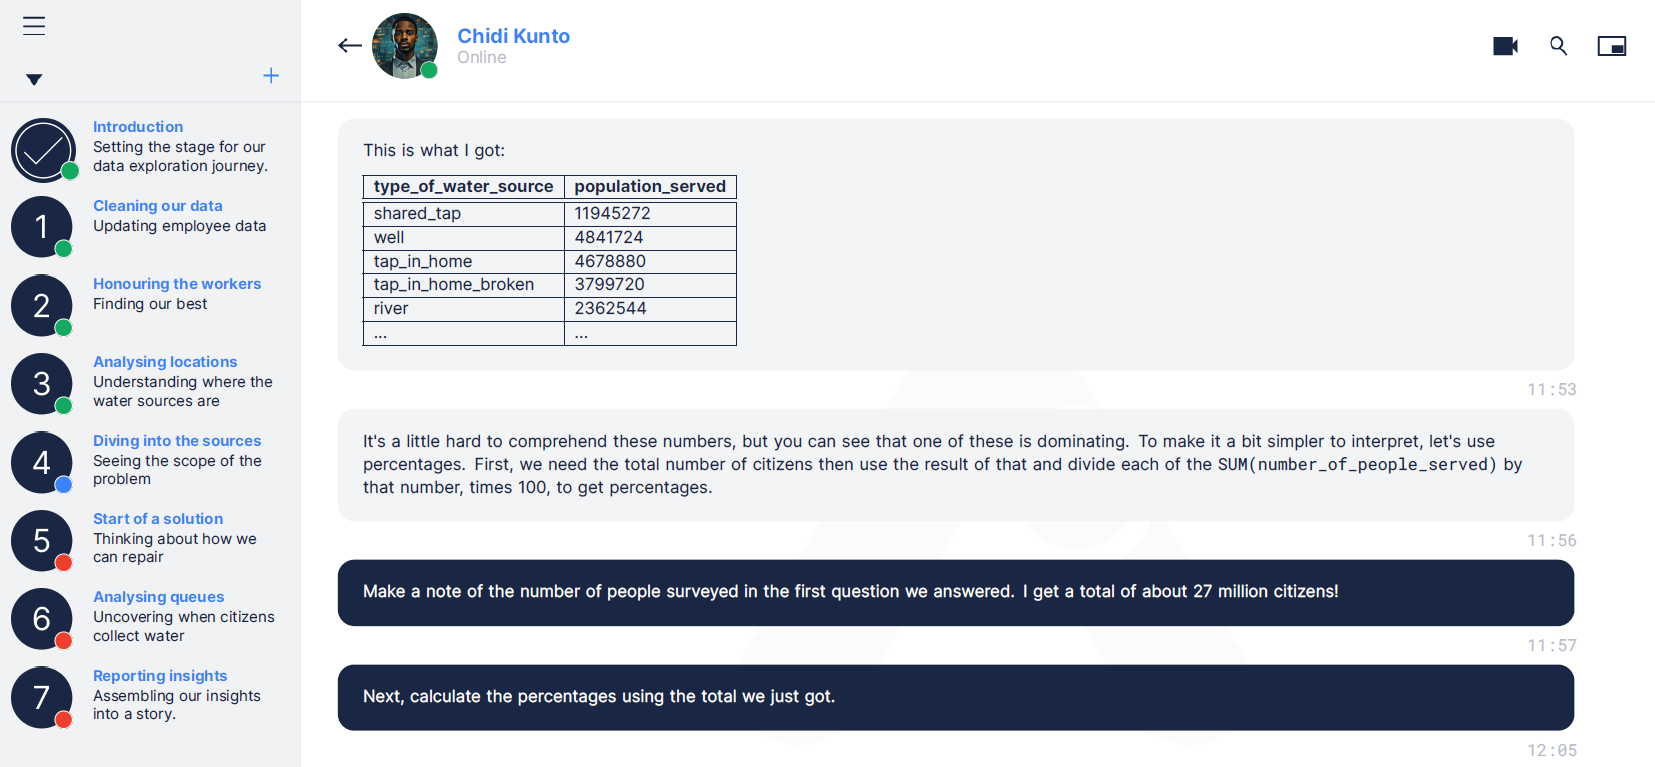

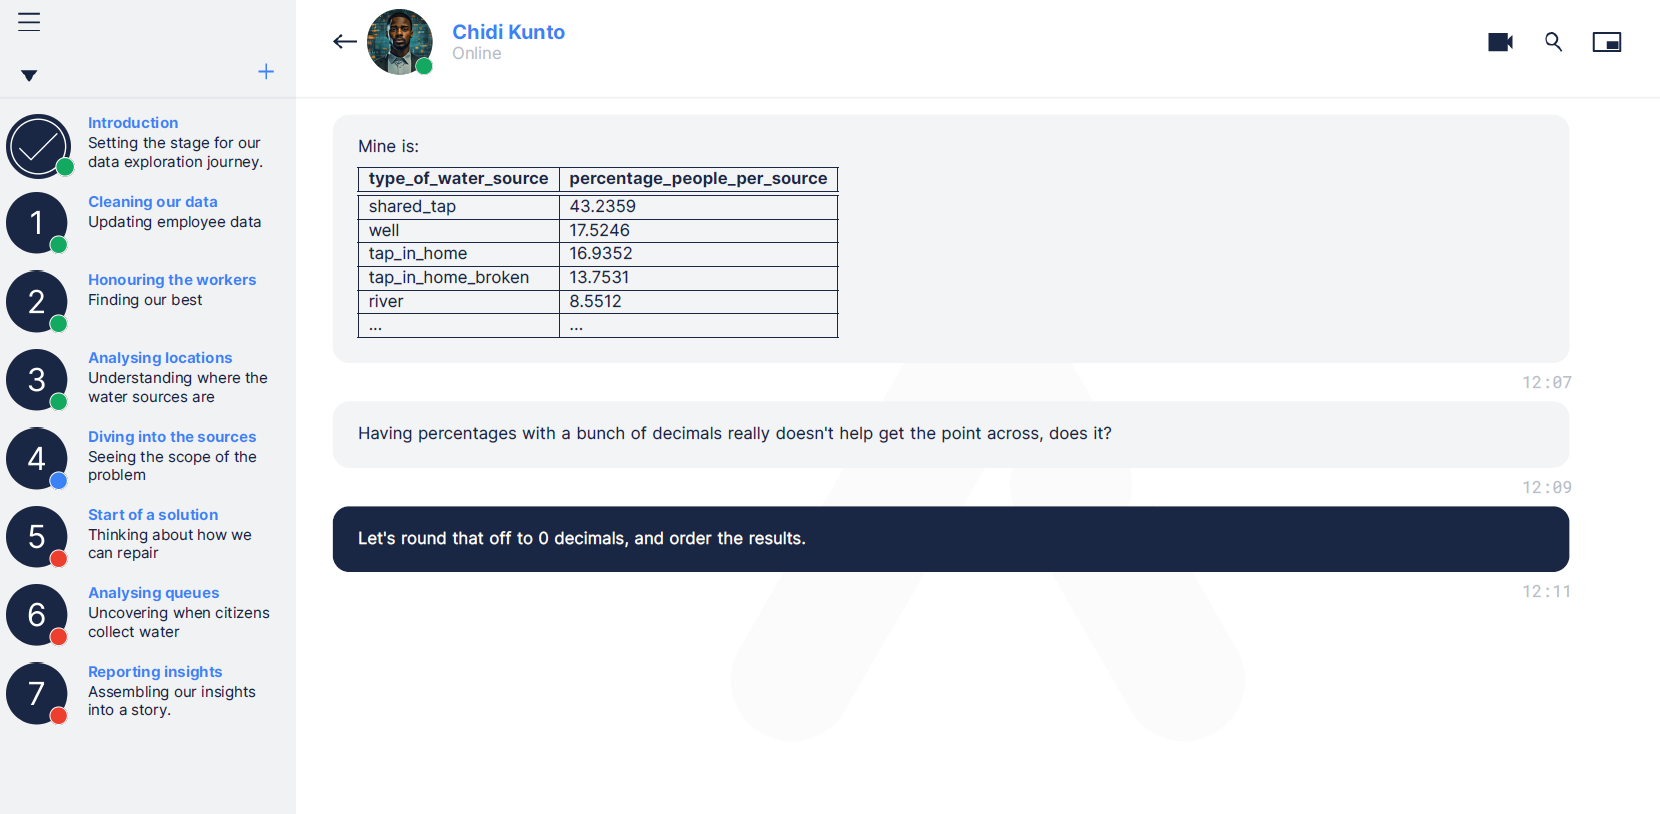

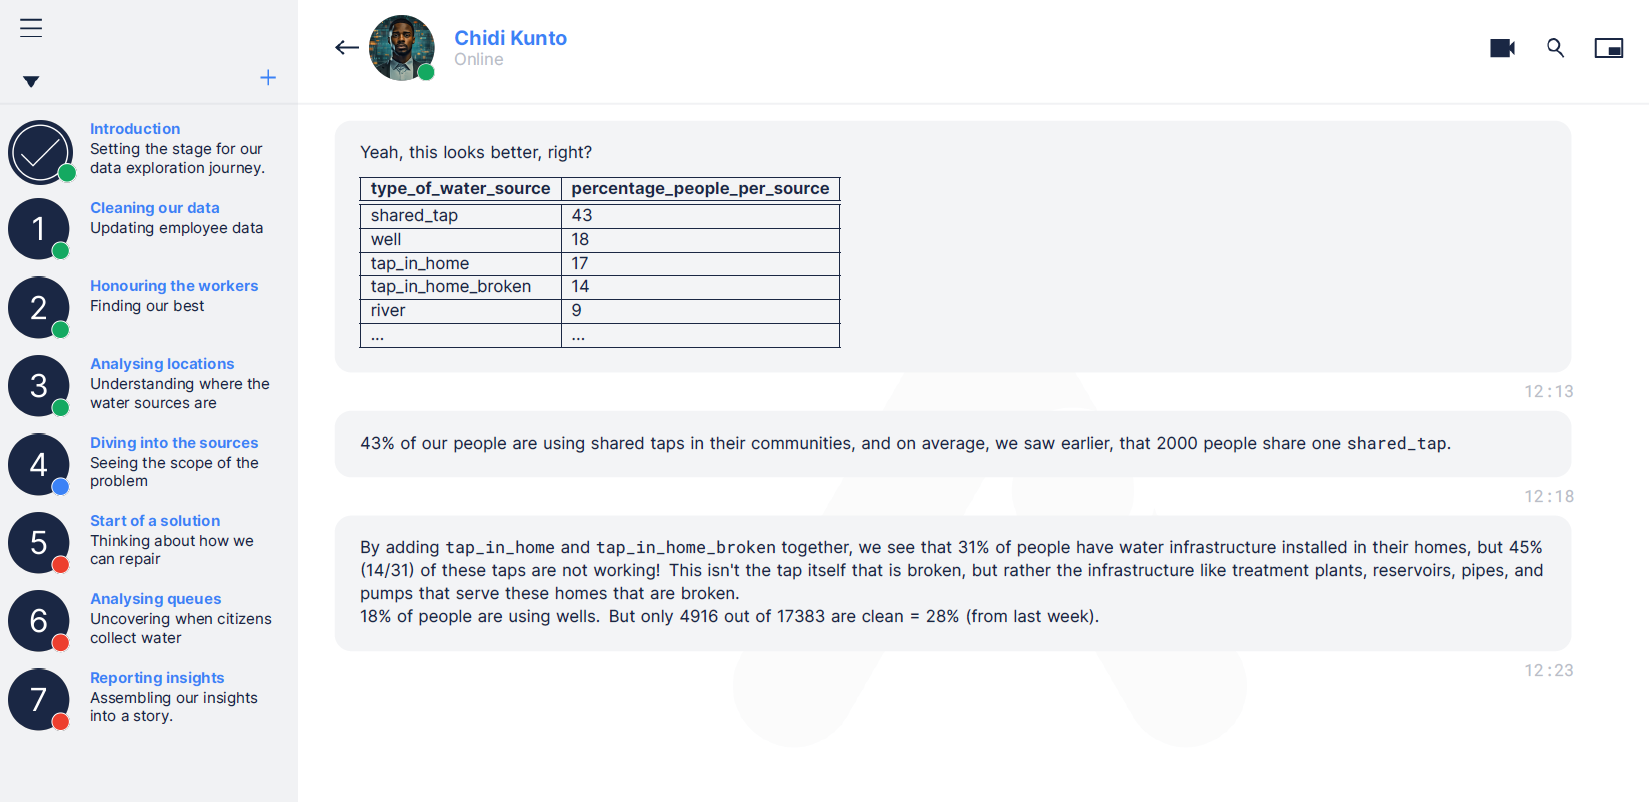

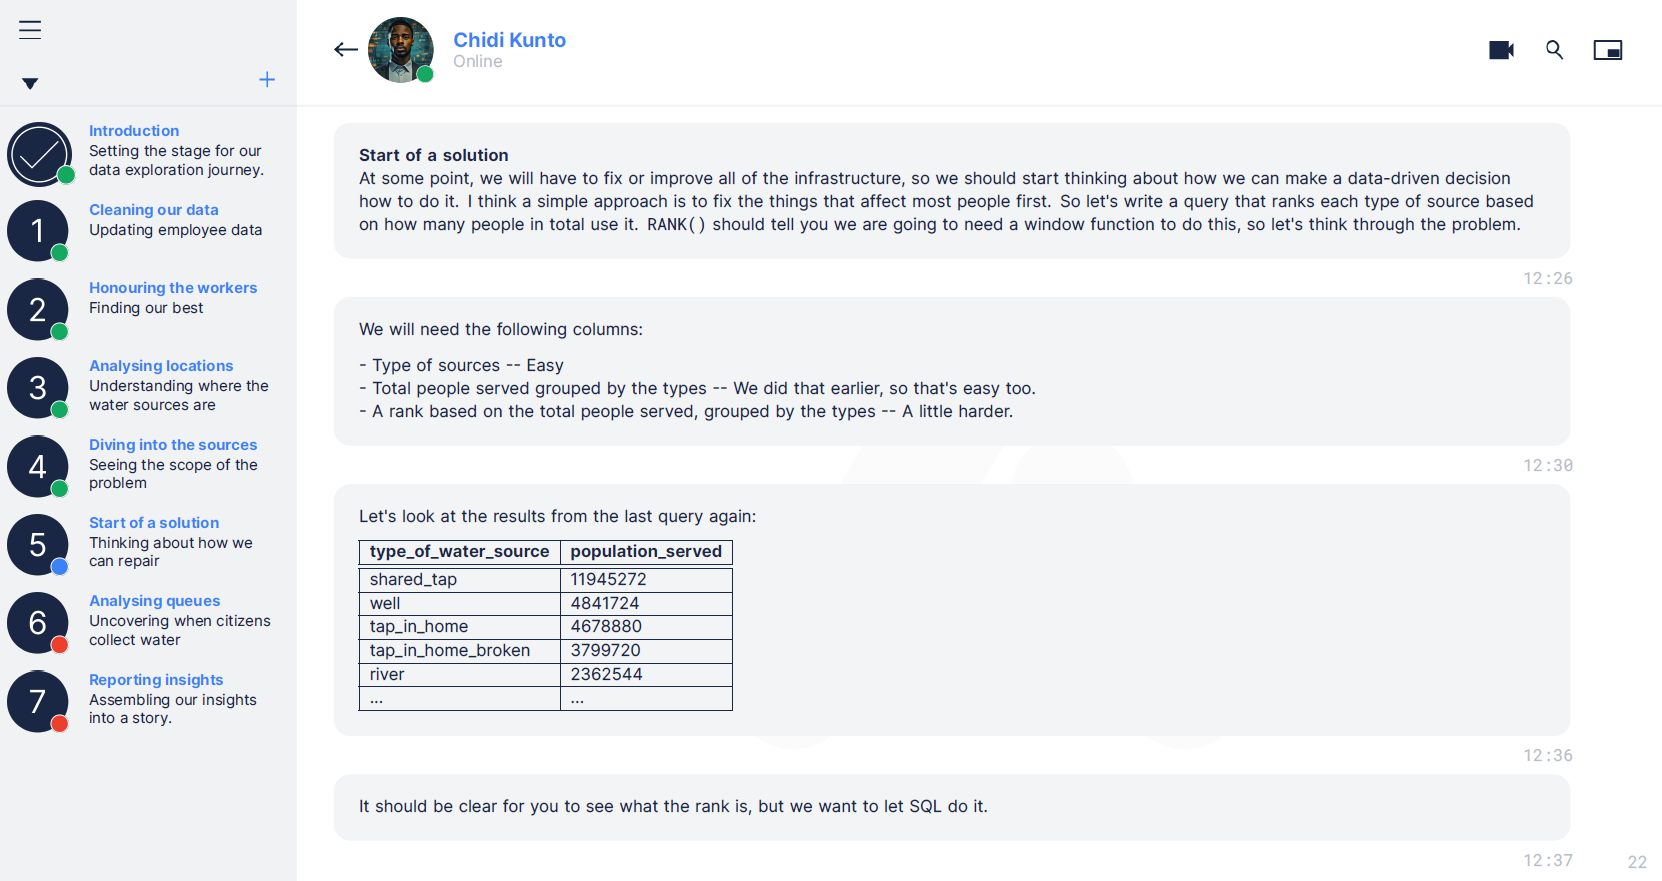

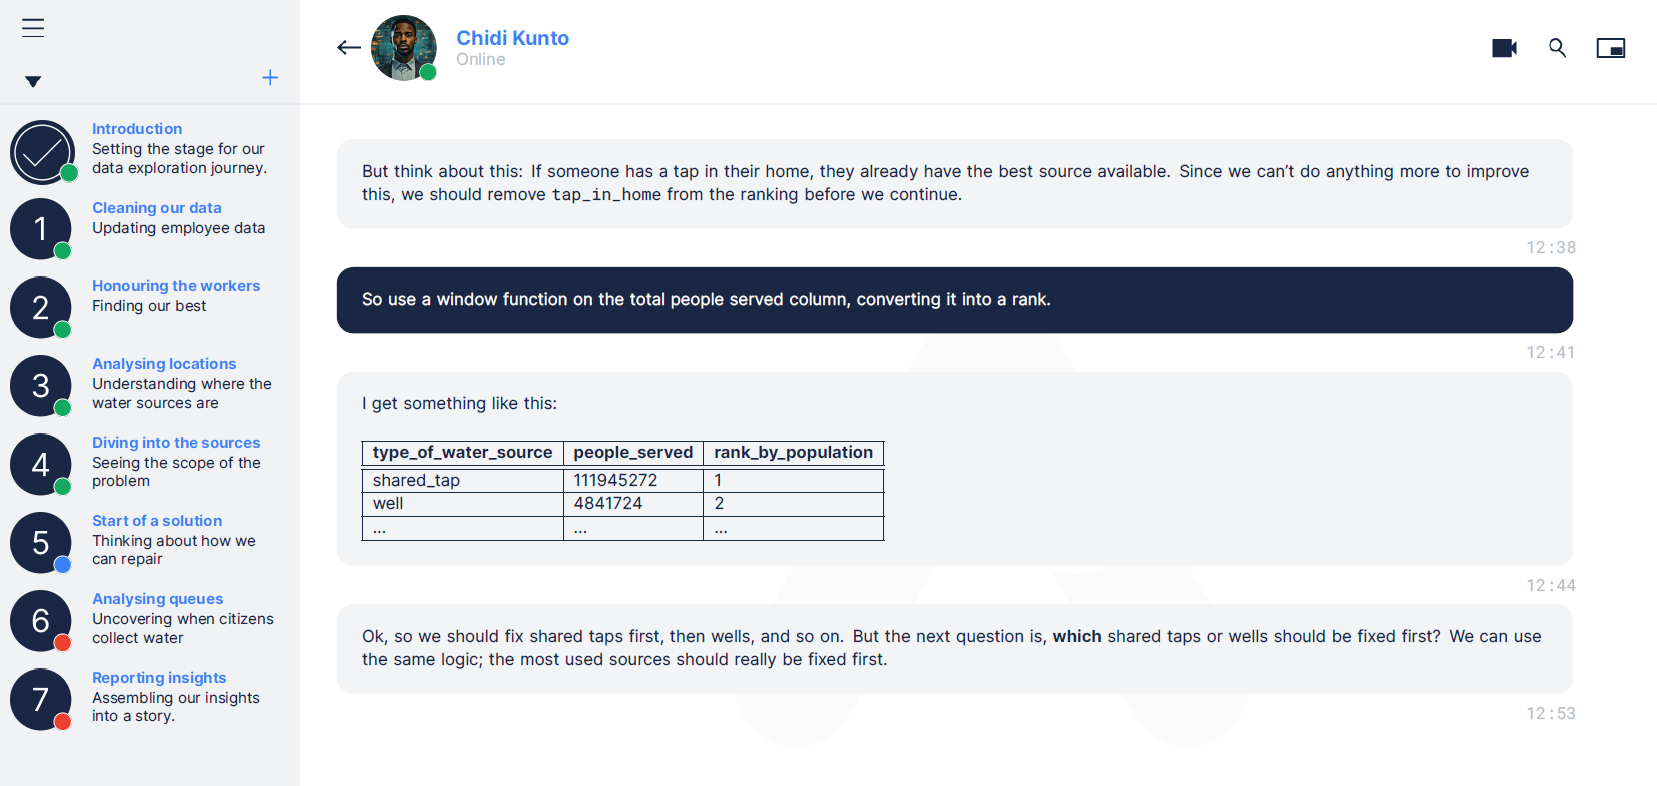

In [ ]:
%%sql
SELECT 
    type_of_water_source, 
    SUM(number_of_people_served) AS population_served,
    ROUND(SUM(number_of_people_served) * 100.0 / (SELECT SUM(number_of_people_served) FROM water_source),0) AS percentage,
    RANK() OVER (ORDER BY SUM(number_of_people_served) DESC) AS rank_population_served
FROM water_source
GROUP BY type_of_water_source
ORDER BY population_served DESC;


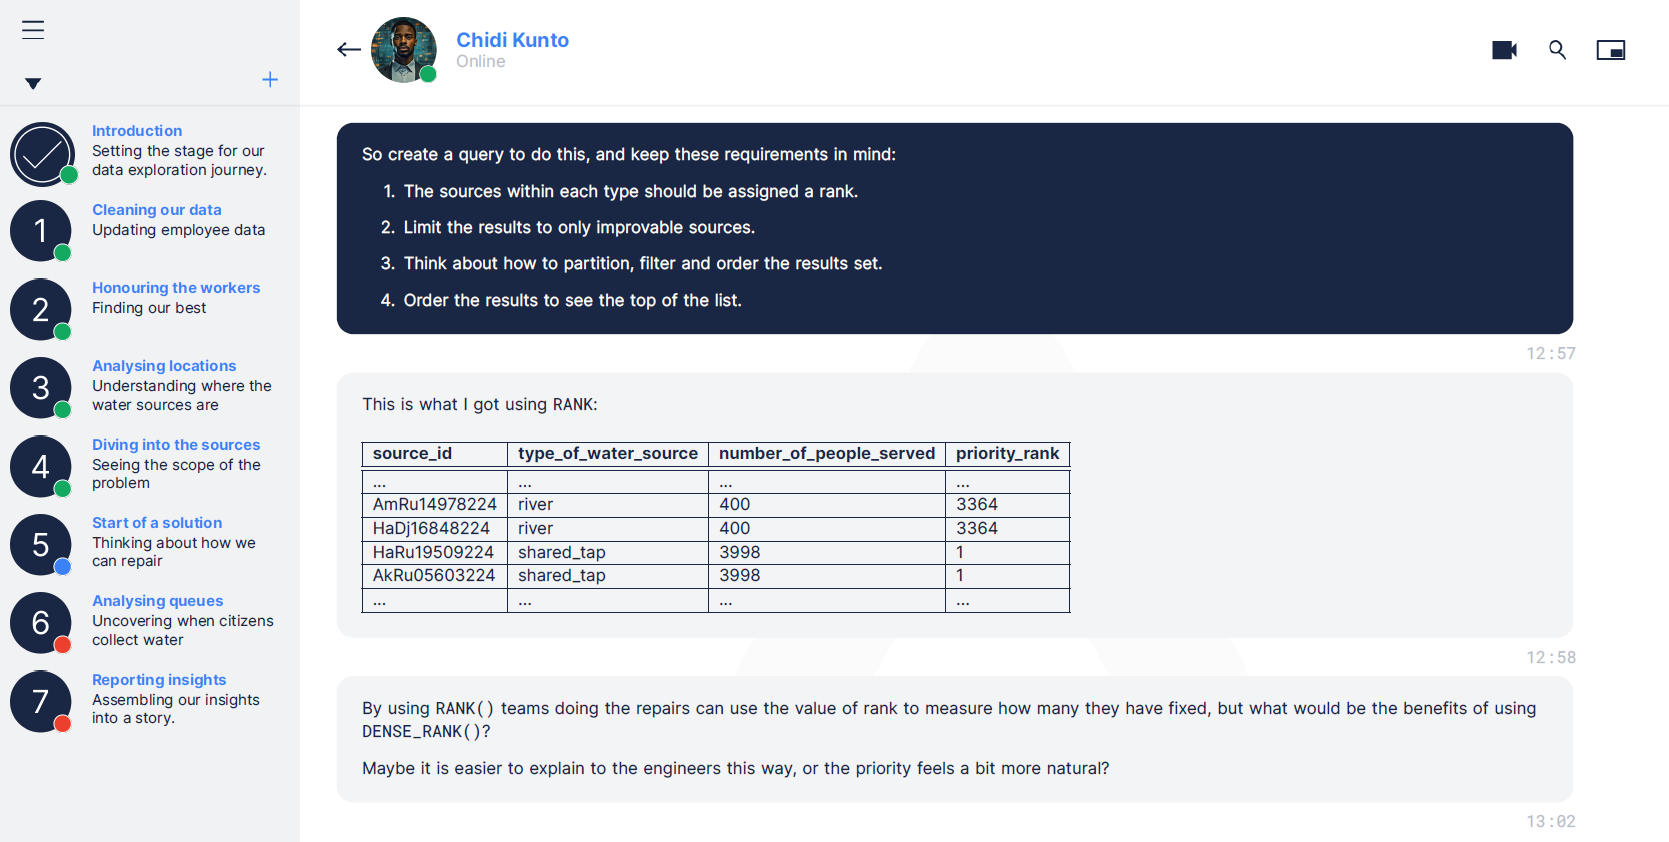

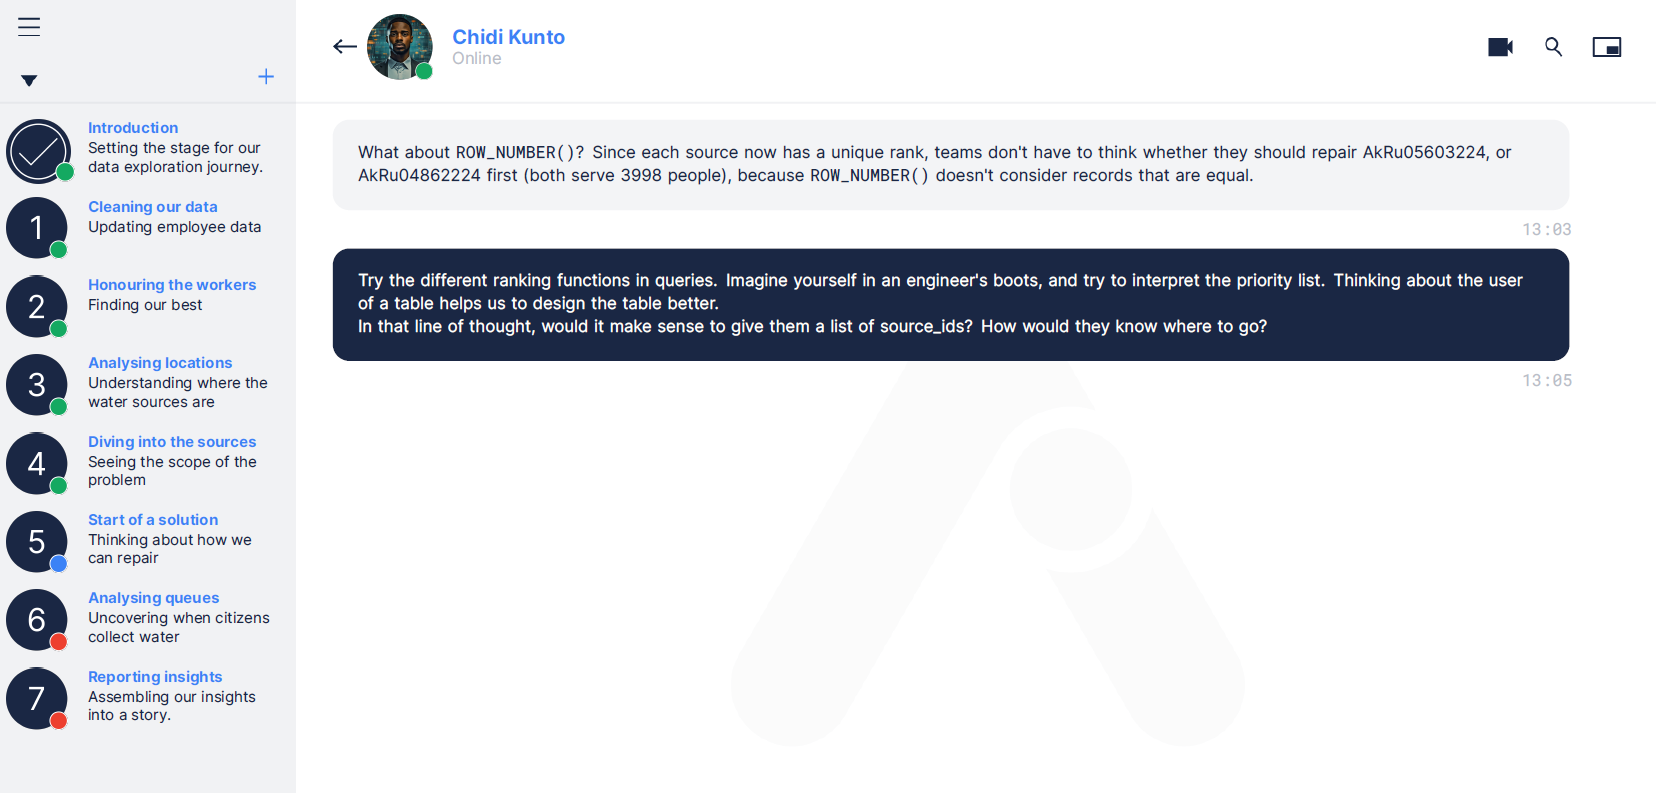

In [ ]:
%%sql
SELECT *,
DENSE_RANK() OVER (ORDER BY number_of_people_served DESC) AS rank_people_served,
RANK() OVER (ORDER BY number_of_people_served DESC) AS rank_people_served_with_gaps,
ROW_NUMBER() OVER (ORDER BY number_of_people_served DESC) AS row_number_people_served
FROM water_source LIMIT 5;

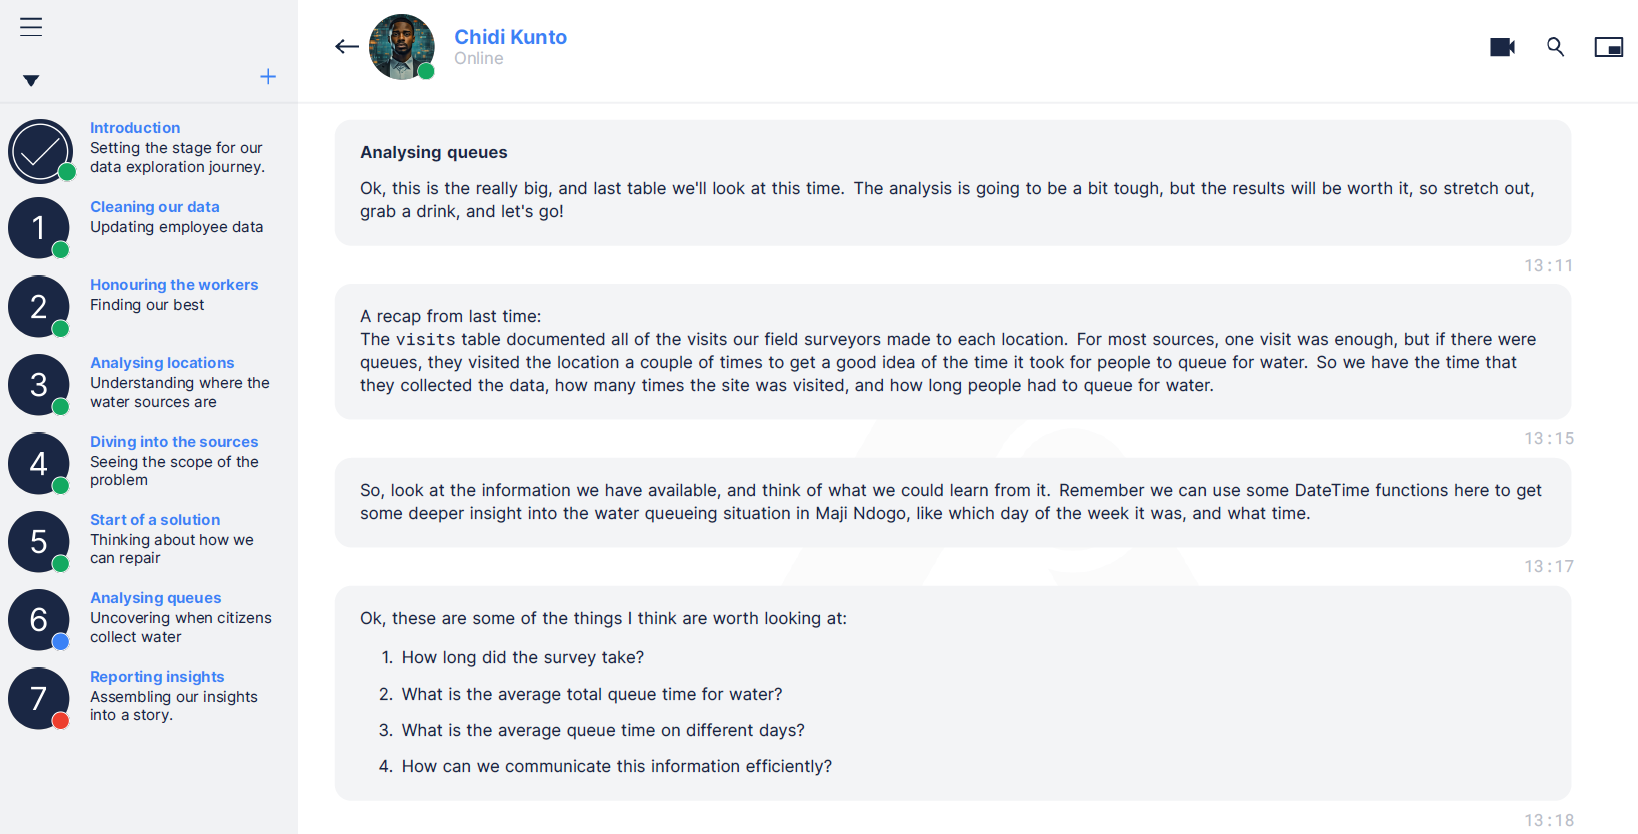

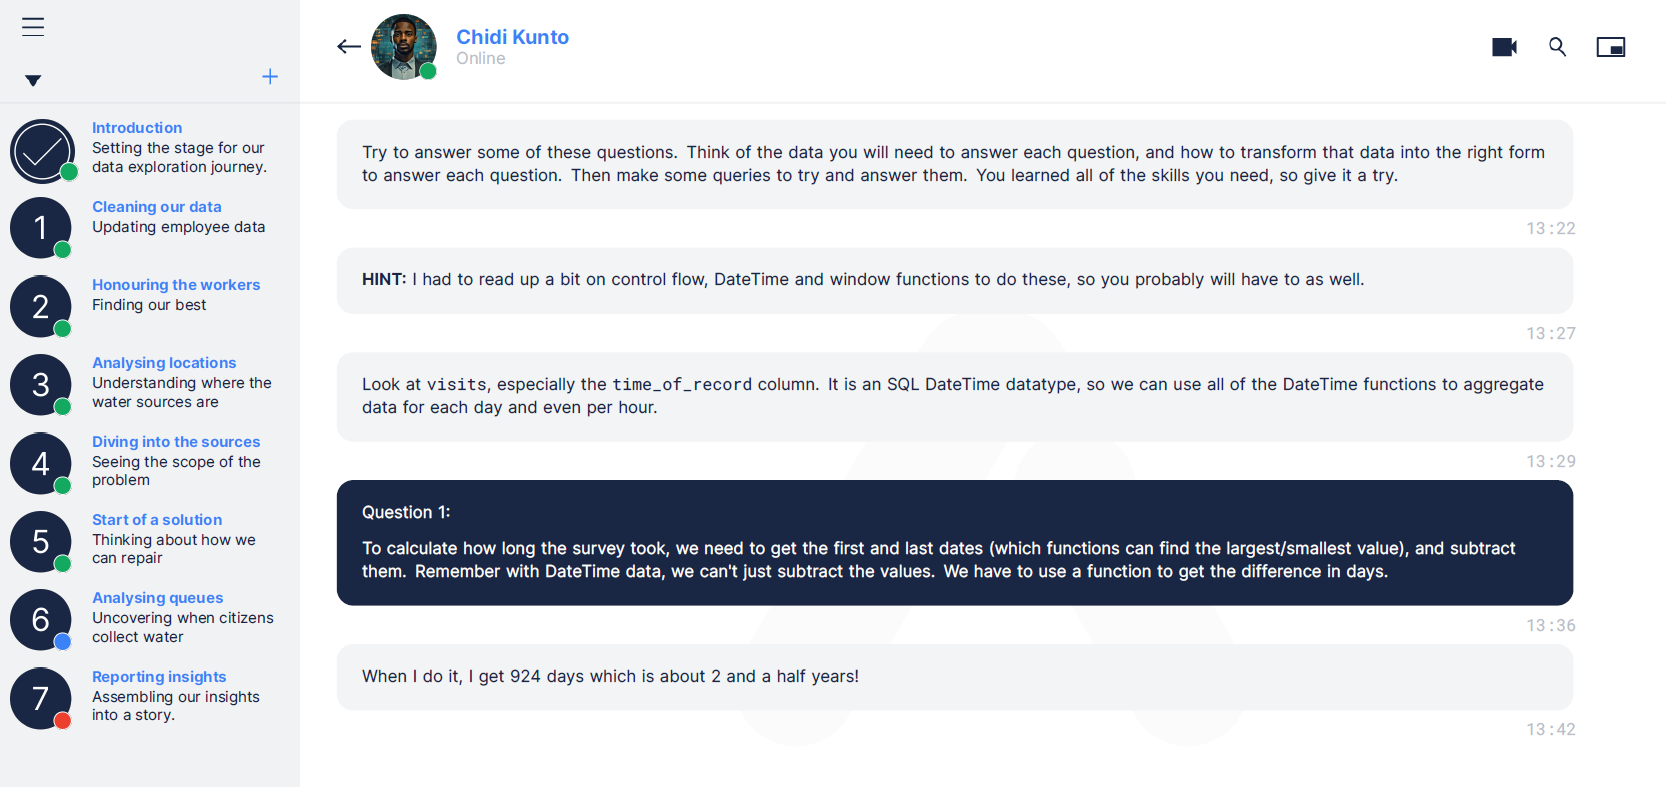

In [ ]:
%%sql
SELECT * FROM visits LIMIT 5;

In [ ]:
%%sql
-- How long did the survey take?
SELECT 
    MIN(time_of_record) AS earliest_date,
    MAX(time_of_record) AS latest_date,
    DATEDIFF(MAX(time_of_record), MIN(time_of_record)) AS days_difference
FROM visits;

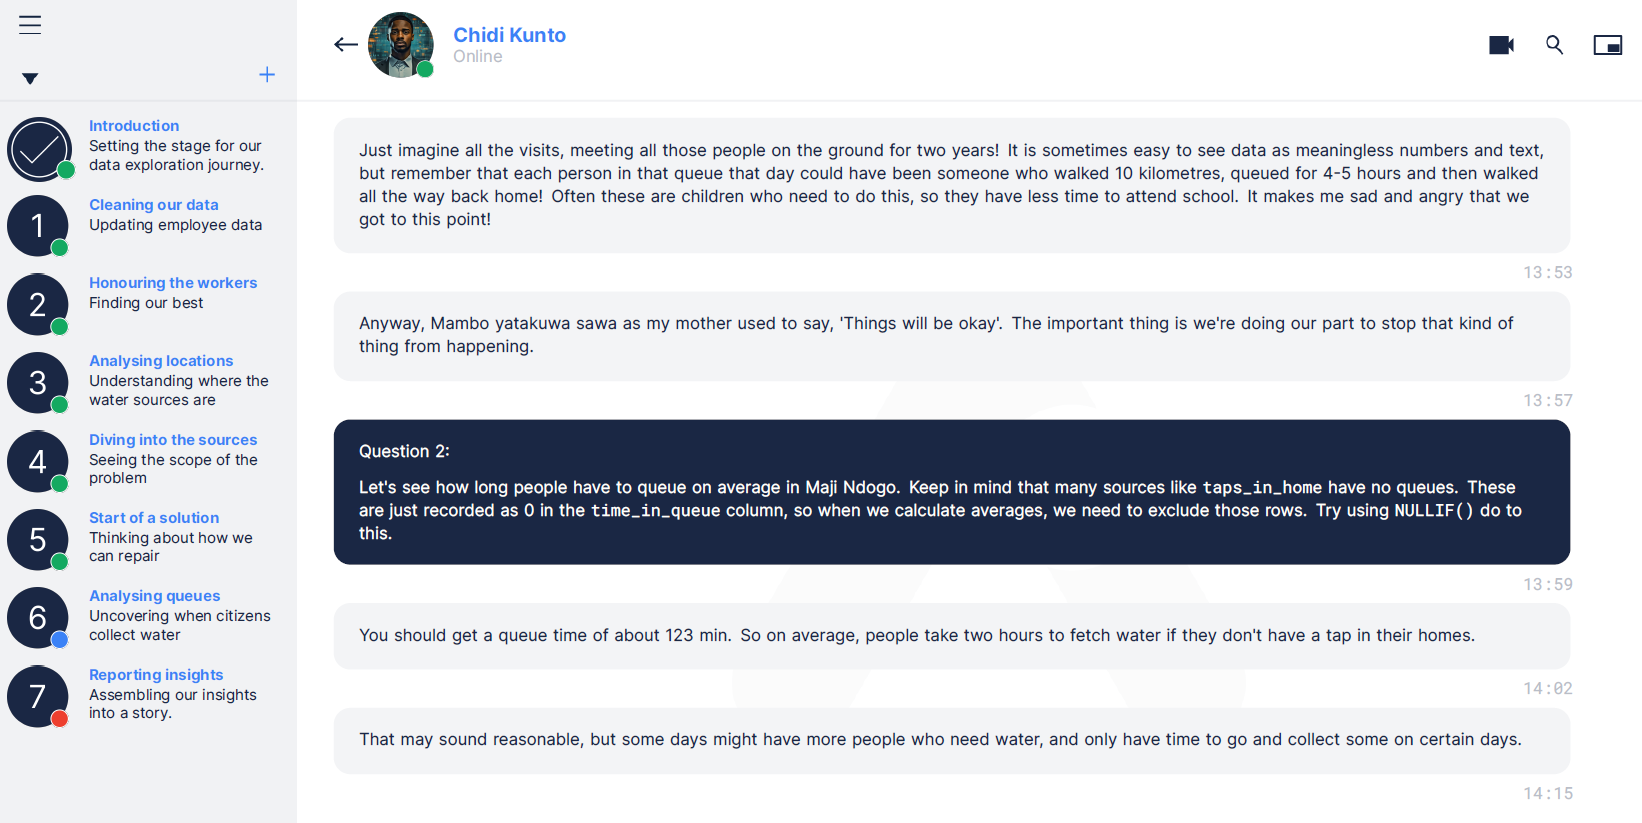

In [ ]:
%%sql
SELECT 
    AVG(time_in_queue) AS avg_time_in_queue 
FROM visits
WHERE time_in_queue != 0;


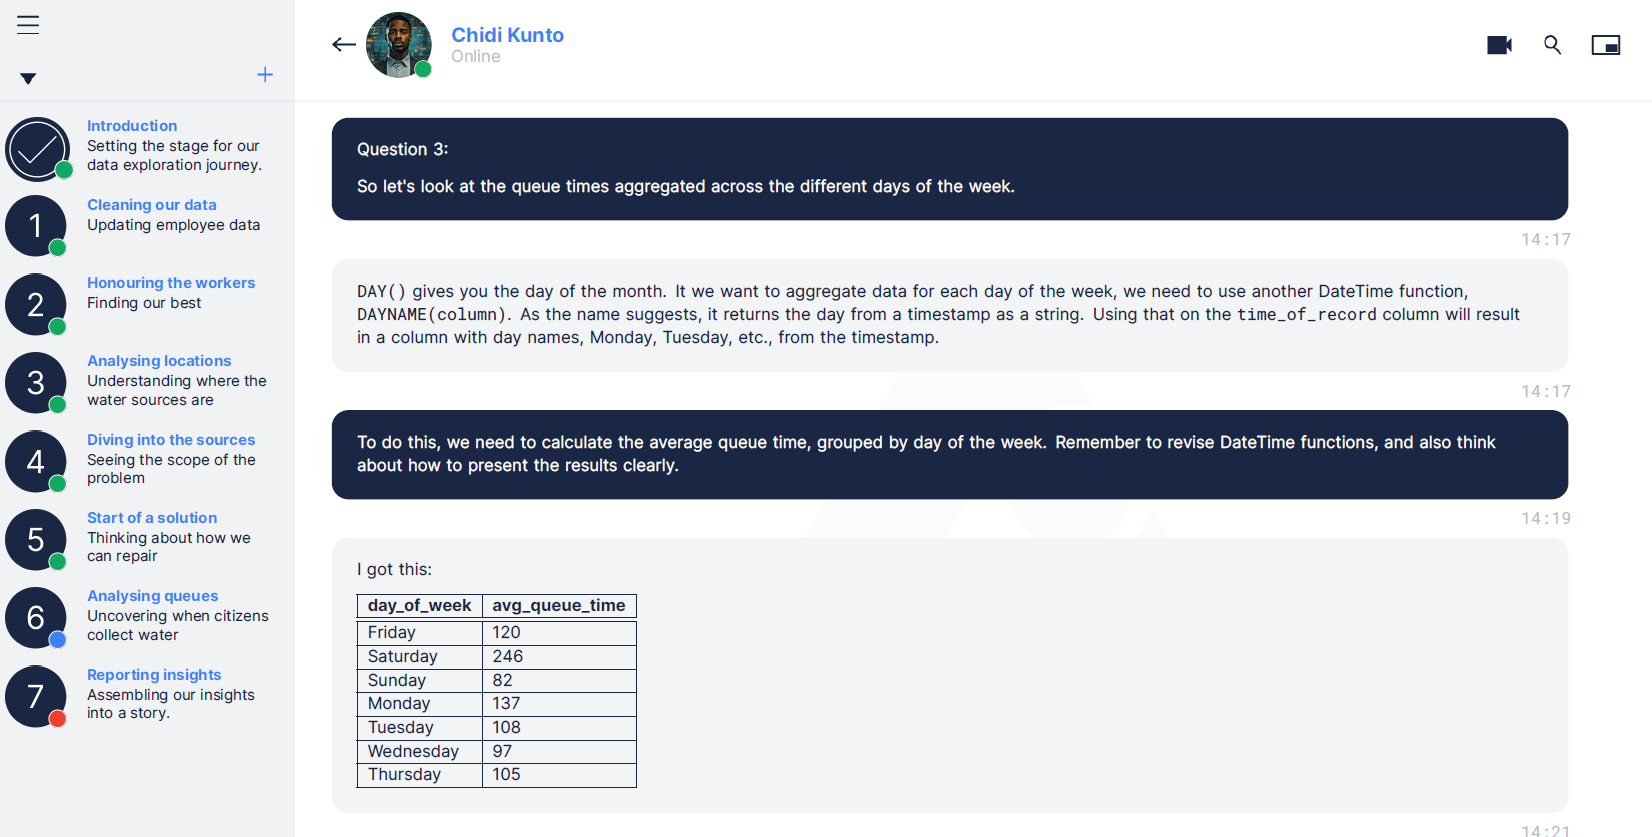

In [ ]:
%%sql
SELECT 
    DAYNAME(time_of_record) AS day_name,
    ROUND(AVG(time_in_queue),0) AS avg_time_in_queue
FROM visits
WHERE time_in_queue != 0
GROUP BY DAYNAME(time_of_record)
ORDER BY avg_time_in_queue DESC;


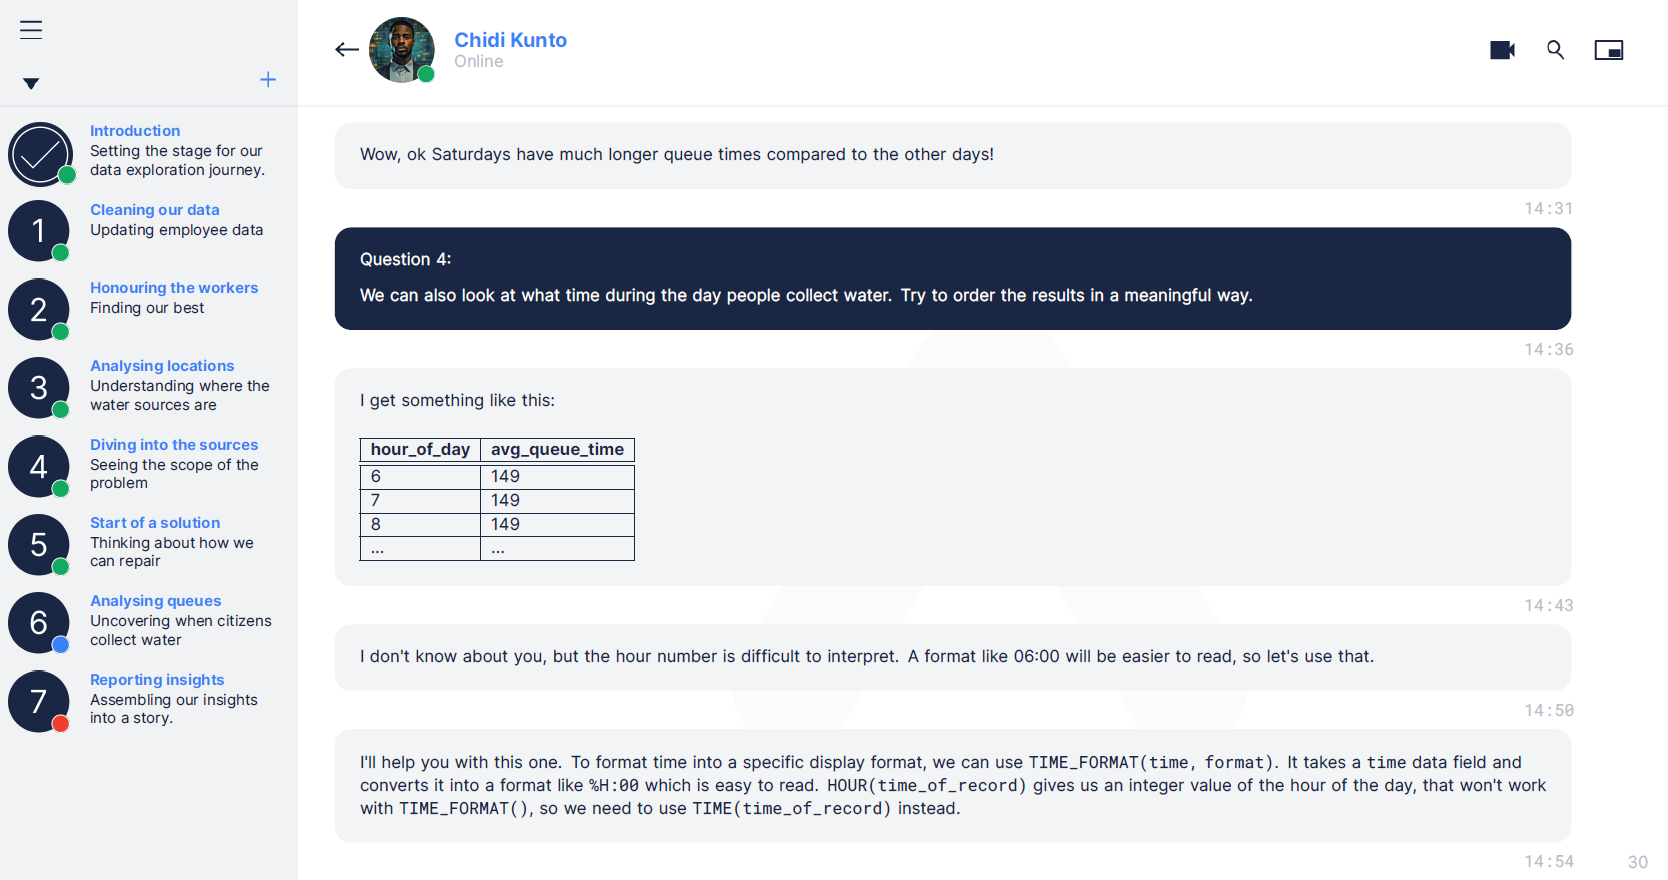

In [ ]:
%%sql
SELECT 
    DATE_FORMAT(time_of_record, '%H:00') AS hour_of_day,
    ROUND(AVG(time_in_queue),0) AS avg_time_in_queue
FROM visits
WHERE time_in_queue <> 0
GROUP BY hour_of_day
ORDER BY hour_of_day;

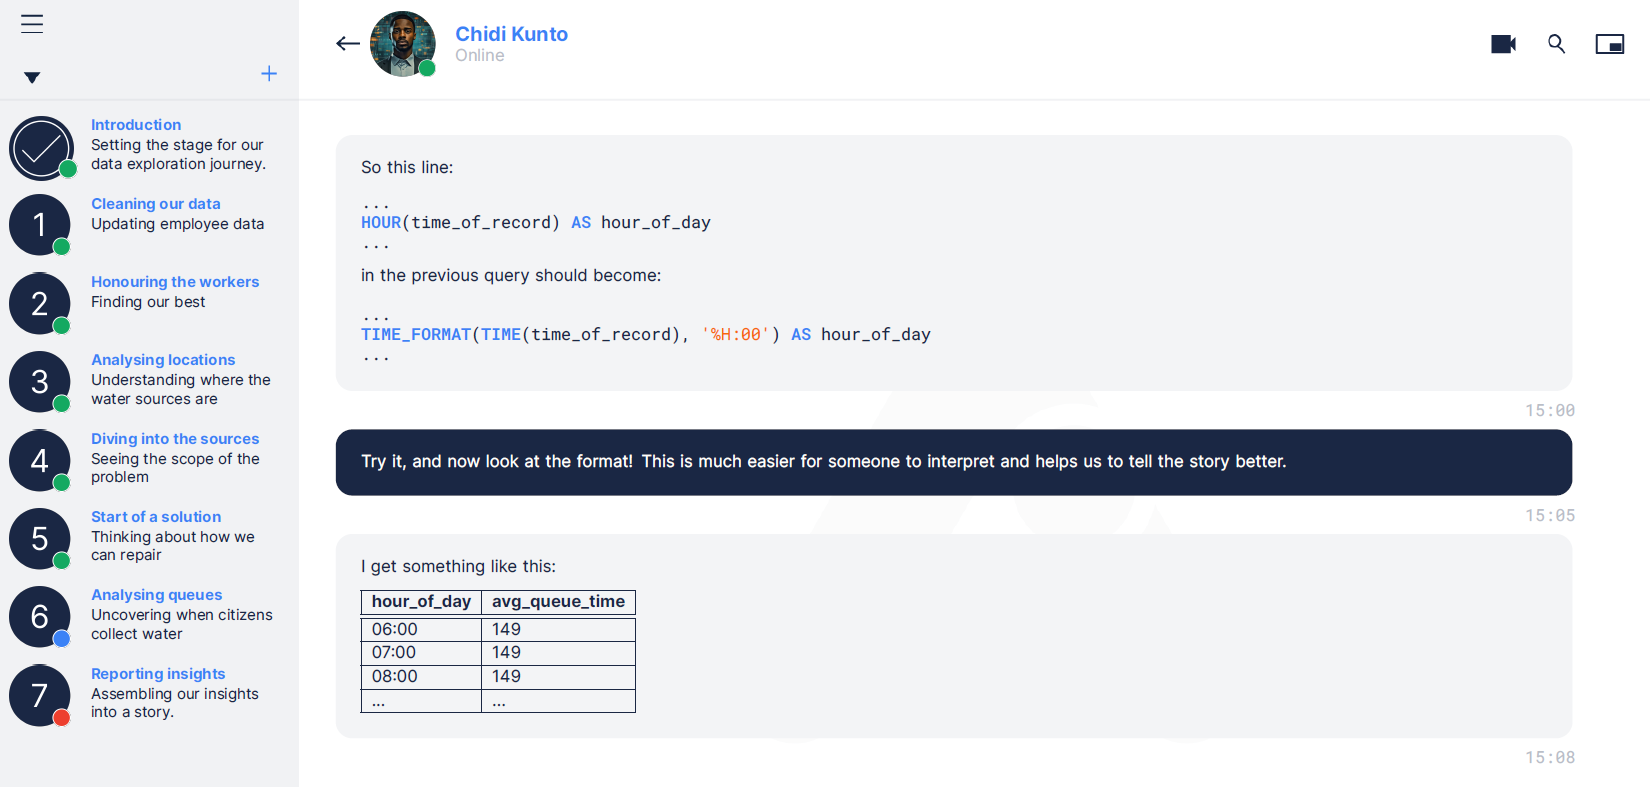

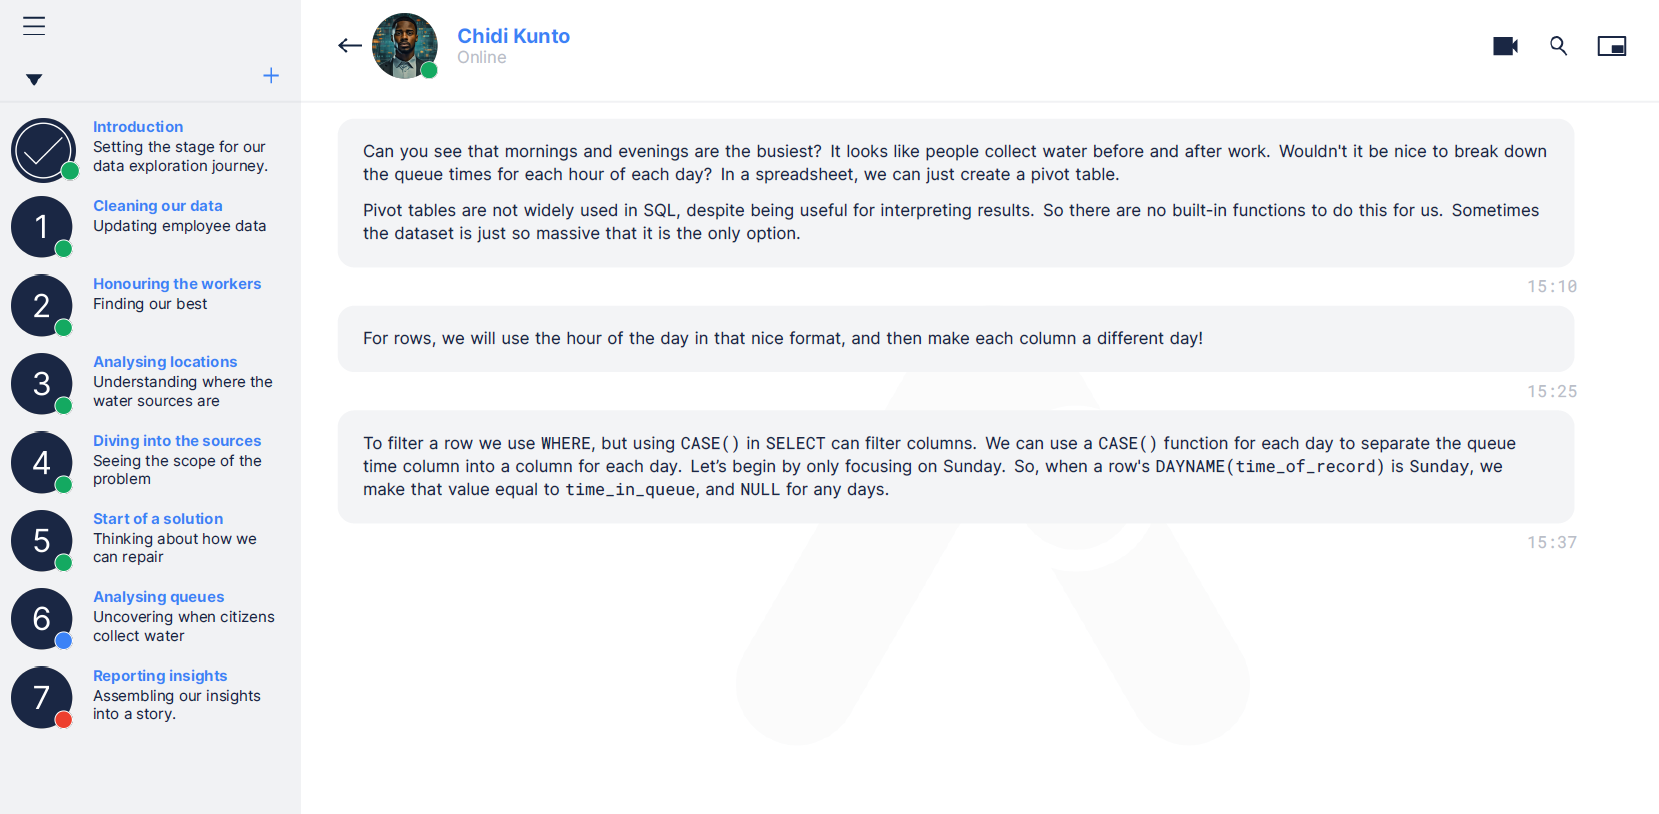

In [ ]:
%%sql
SELECT
    TIME_FORMAT(TIME(time_of_record), '%H:00') AS hour_of_day,
    DAYNAME(time_of_record),
    CASE
        WHEN DAYNAME(time_of_record) = 'Sunday' THEN time_in_queue
        ELSE NULL
    END AS Sunday
FROM visits
WHERE time_in_queue != 0 -- this exludes other sources with 0 queue times.
LIMIT 25;

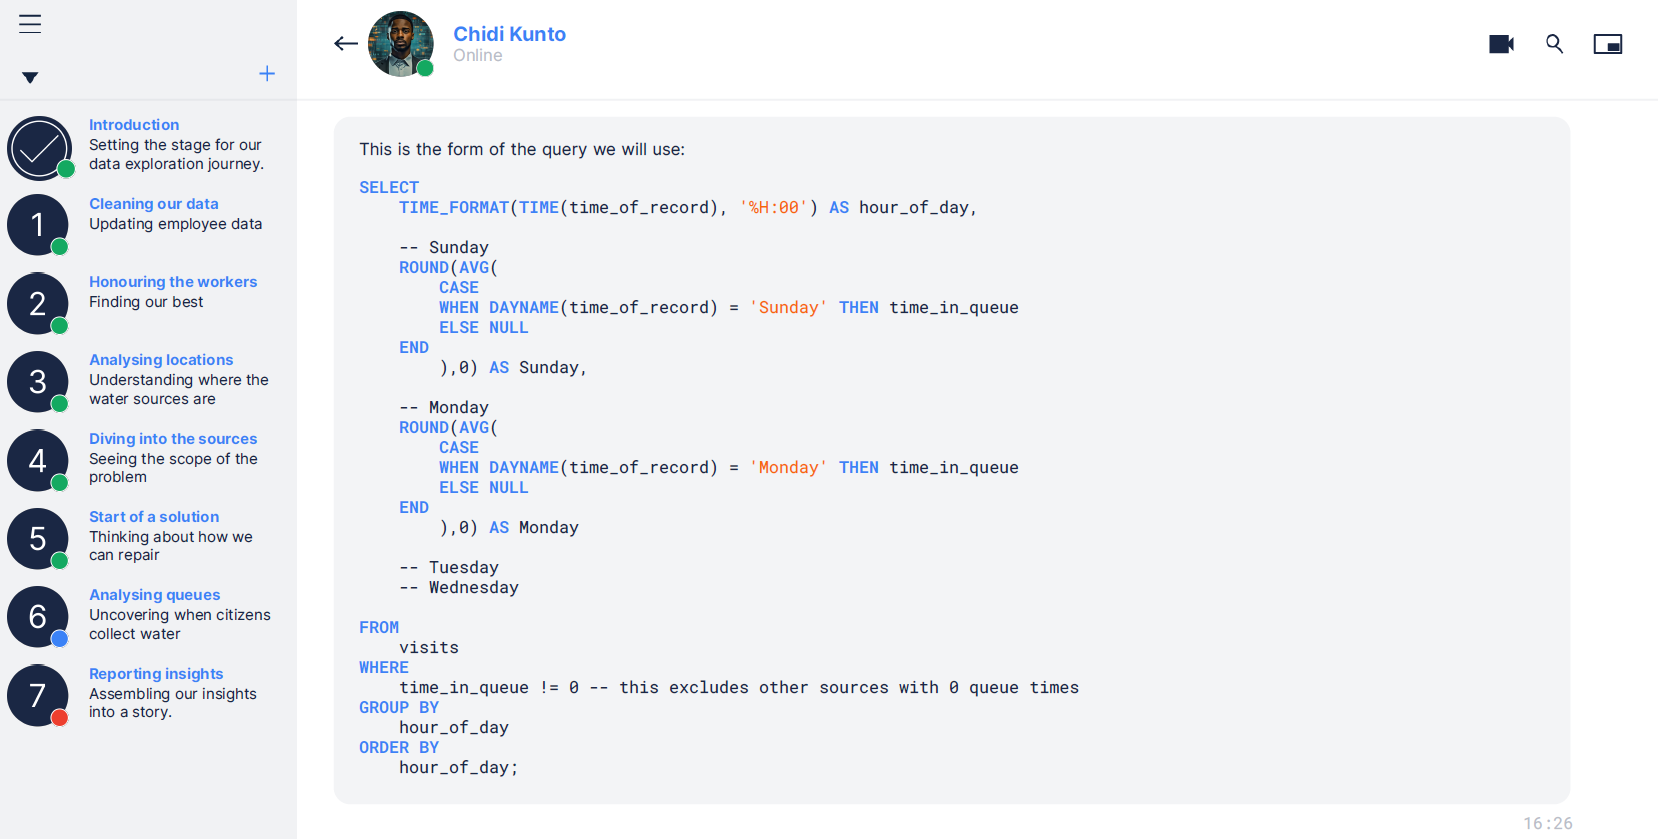

In [ ]:
%%sql
SELECT
    TIME_FORMAT(TIME(time_of_record), '%H:00') AS hour_of_day,
    -- Sunday
    ROUND(AVG(
        CASE WHEN DAYNAME(time_of_record) = 'Sunday' THEN time_in_queue ELSE NULL END
    ), 0) AS Sunday,
    -- Monday
    ROUND(AVG(
        CASE WHEN DAYNAME(time_of_record) = 'Monday' THEN time_in_queue ELSE NULL END
    ), 0) AS Monday,
    -- Tuesday
    ROUND(AVG(
        CASE WHEN DAYNAME(time_of_record) = 'Tuesday' THEN time_in_queue ELSE NULL END
    ), 0) AS Tuesday,
    -- Wednesday
    ROUND(AVG(
        CASE WHEN DAYNAME(time_of_record) = 'Wednesday' THEN time_in_queue ELSE NULL END
    ), 0) AS Wednesday,
    -- Thursday
    ROUND(AVG(
        CASE WHEN DAYNAME(time_of_record) = 'Thursday' THEN time_in_queue ELSE NULL END
    ), 0) AS Thursday,
    -- Friday
    ROUND(AVG(
        CASE WHEN DAYNAME(time_of_record) = 'Friday' THEN time_in_queue ELSE NULL END
    ), 0) AS Friday,
    -- Saturday
    ROUND(AVG(
        CASE WHEN DAYNAME(time_of_record) = 'Saturday' THEN time_in_queue ELSE NULL END
    ), 0) AS Saturday
FROM visits
WHERE time_in_queue != 0
GROUP BY hour_of_day
ORDER BY hour_of_day;


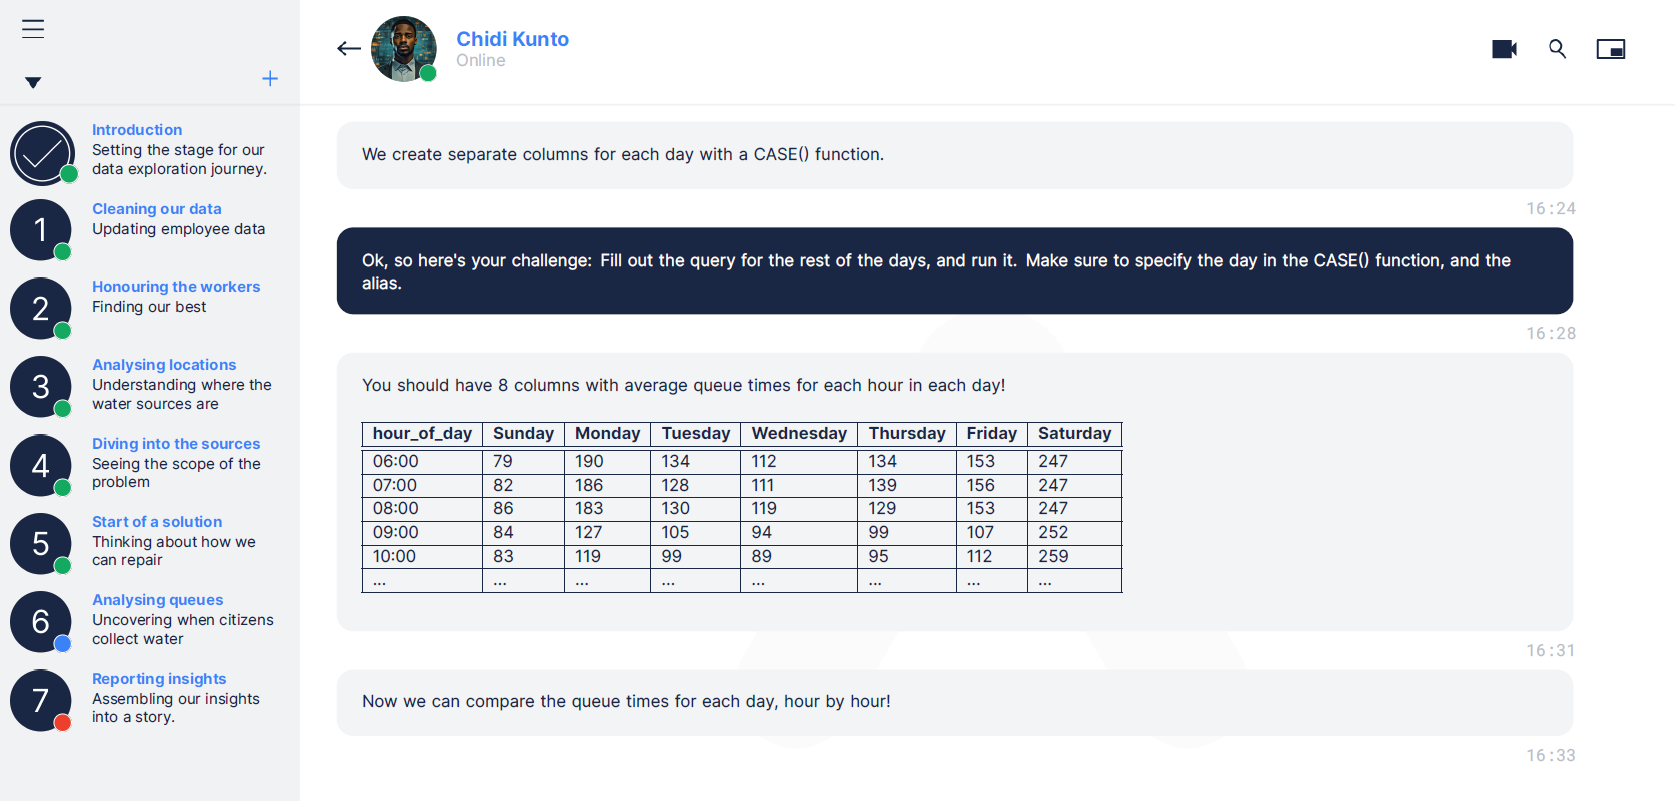

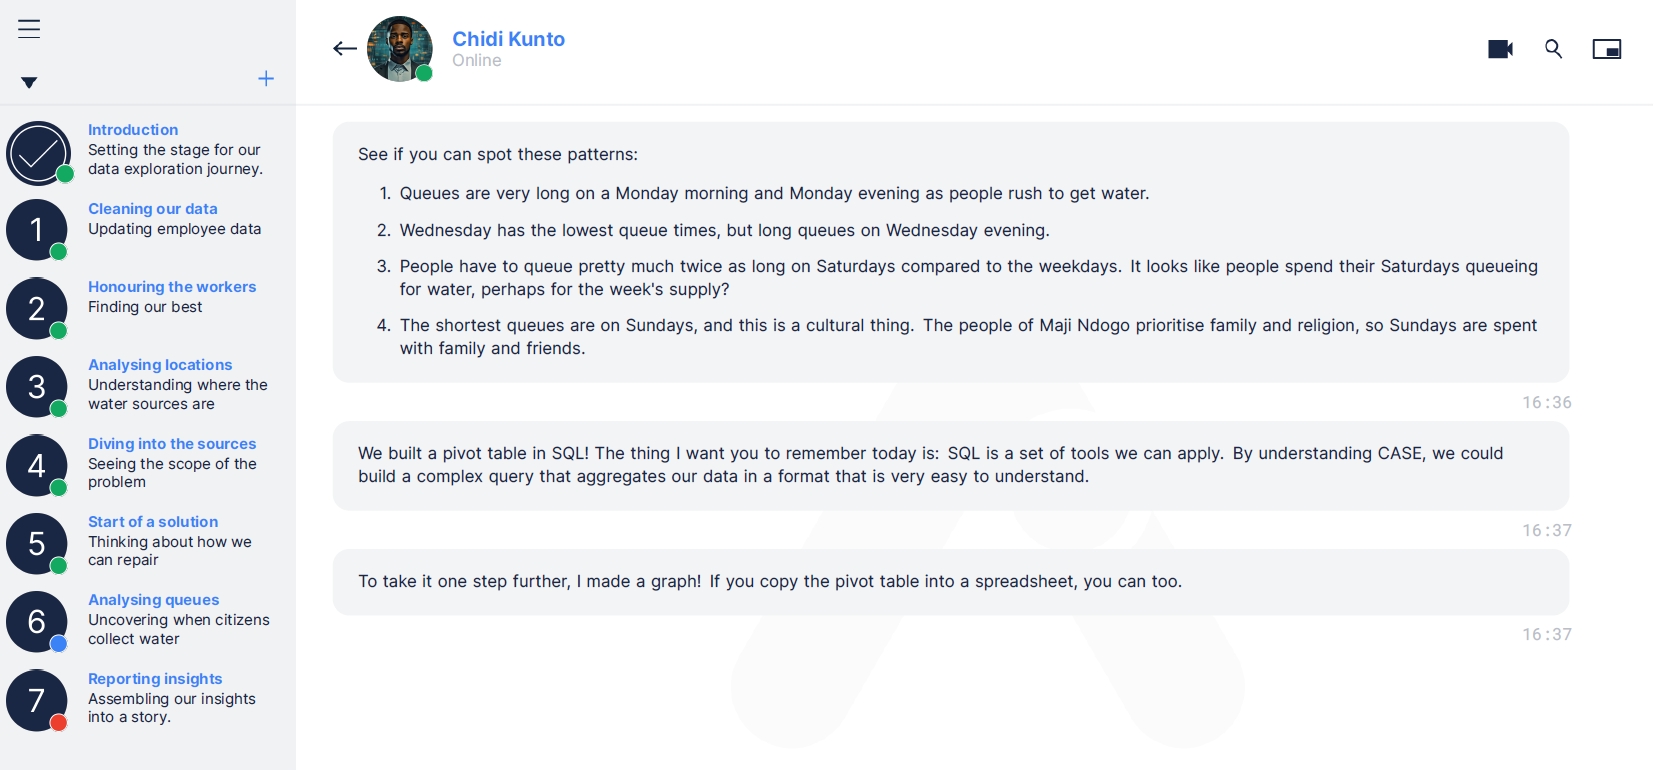

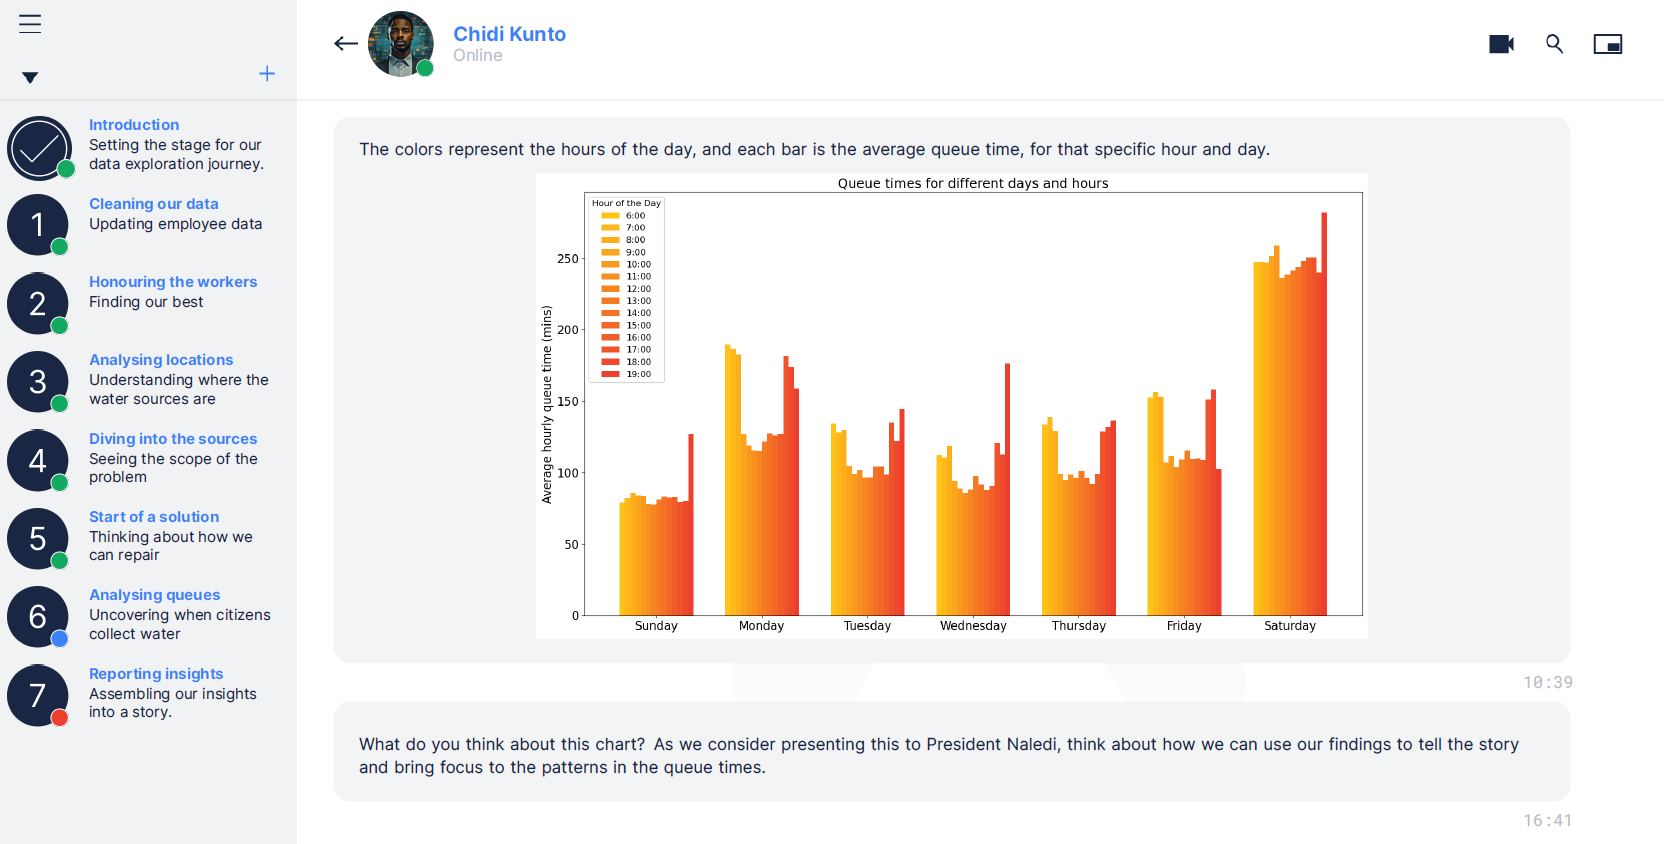

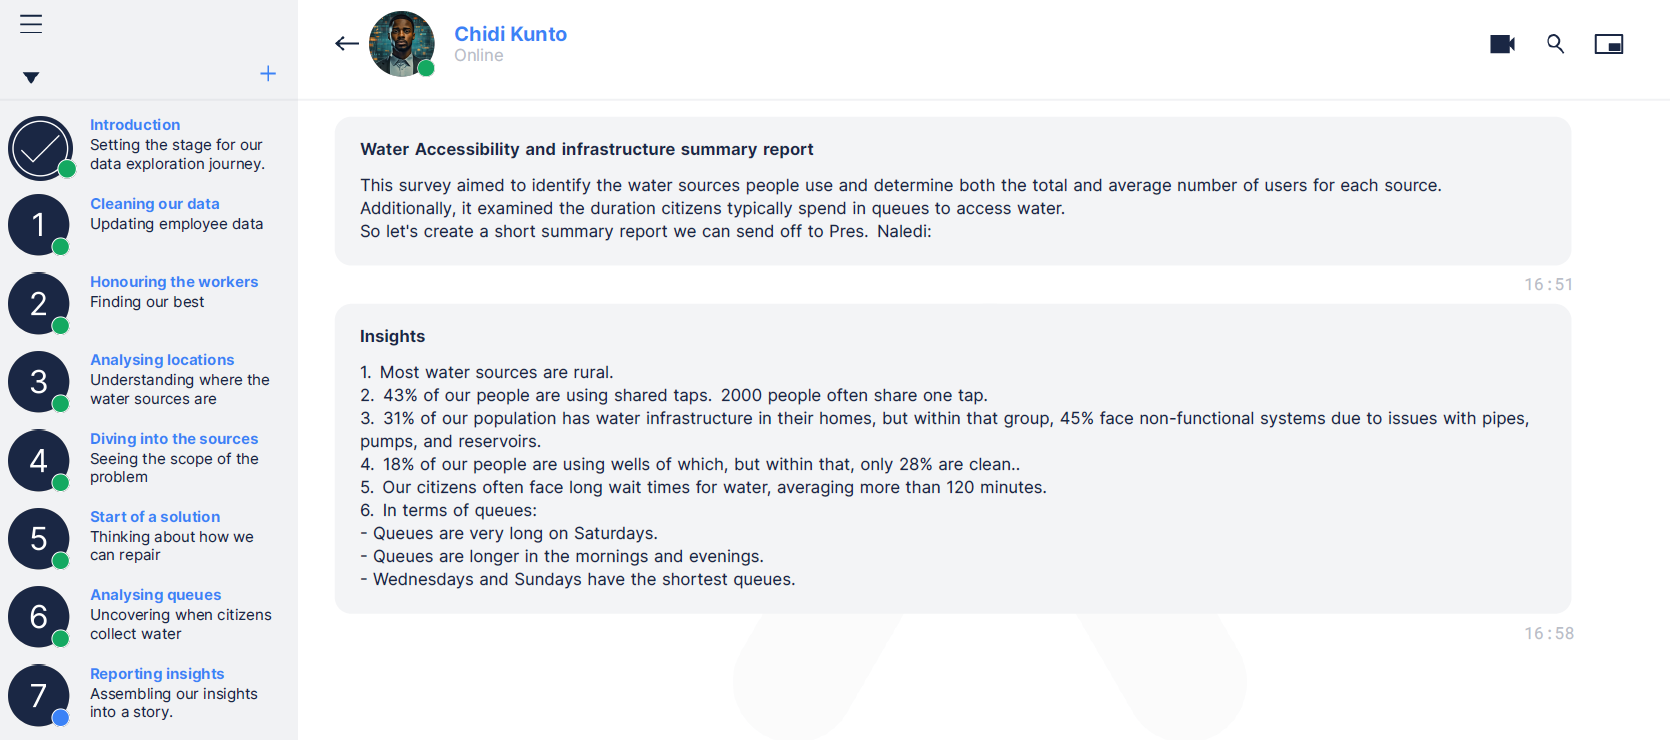

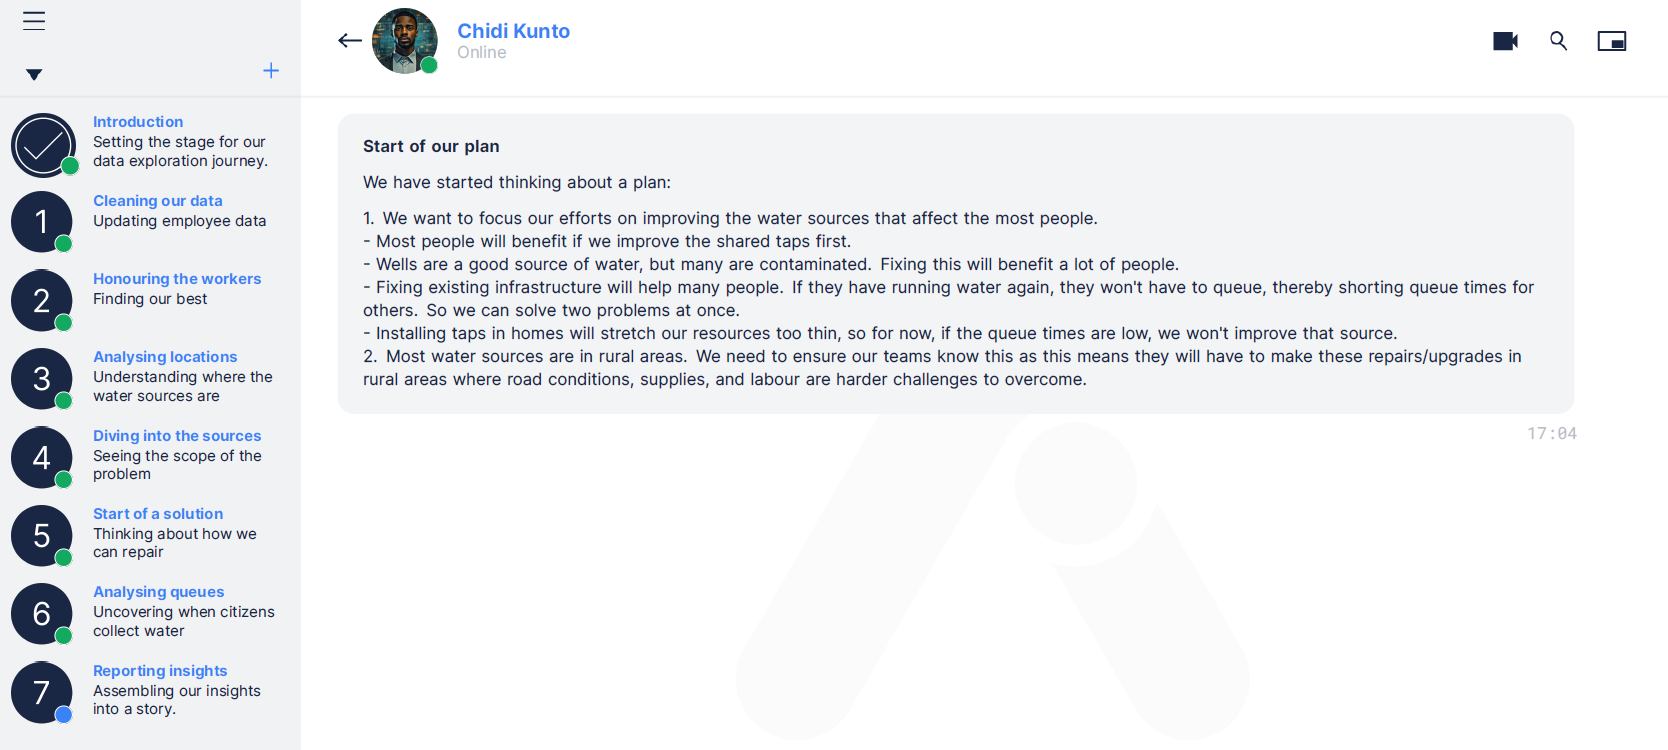

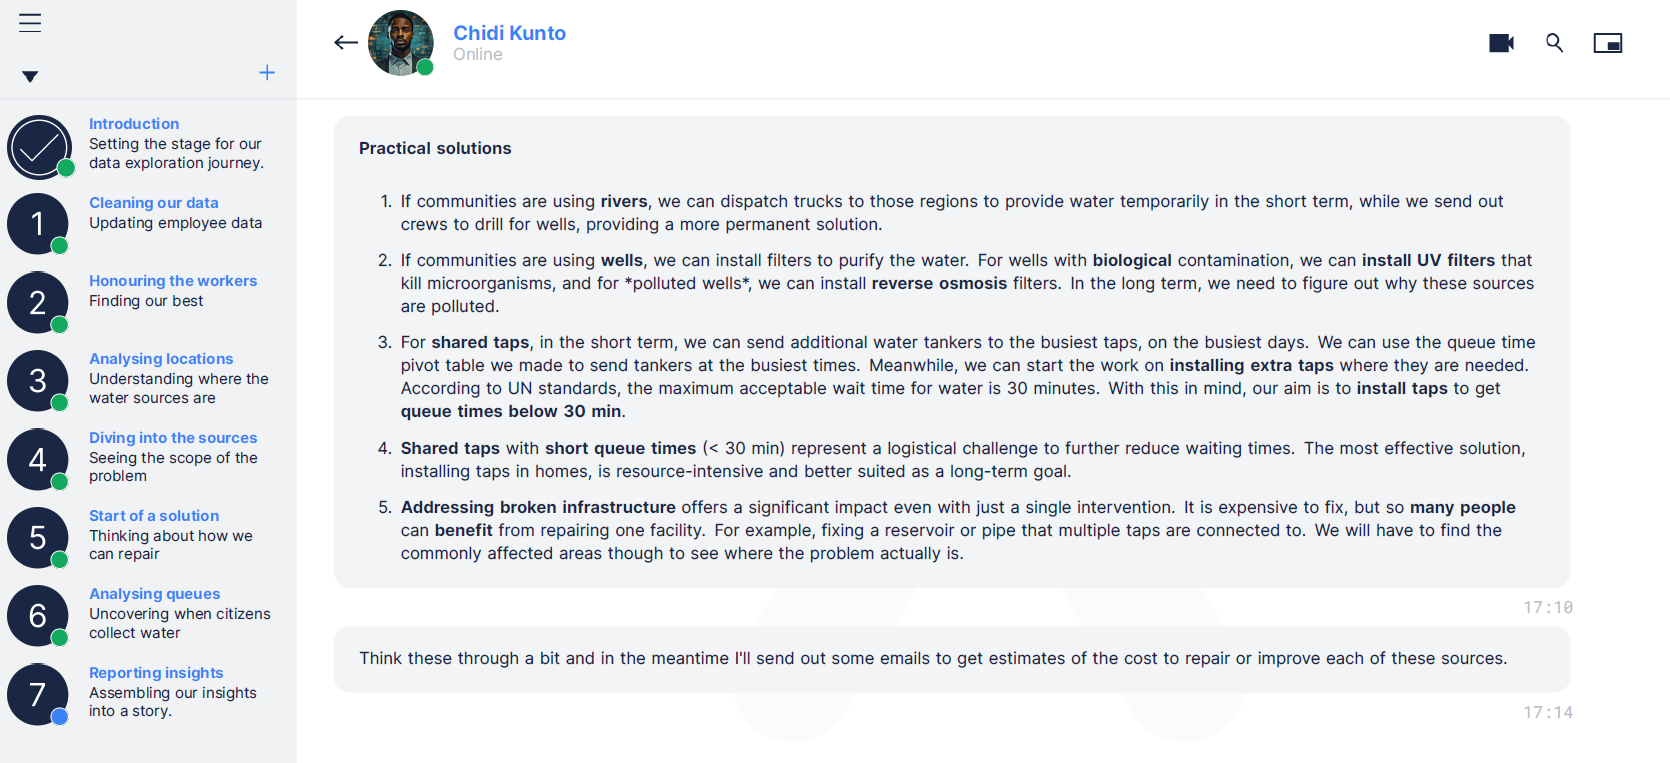

# END OF PART 2